# **Clustering Model Training Notebook**



---
## Setup Environment

In [1]:
# DO NOT MODIFY THE CODE IN THIS CELL
!pip install -q utstd

from utstd.folders import *
from utstd.ipyrenders import *

at = AtFolder(
    course_code=36106,
    assignment="AT3",
)
at.run()

import warnings
warnings.simplefilter(action='ignore')


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip



You can now save your data files in: /Users/shanusharma/Desktop/Python/MDSI/ML/AT3/drive-download-20260516T100846Z-3-001/36106/assignment/AT3/data


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
utstd 0.1.8 requires scikit-learn~=1.5.1, but you have scikit-learn 1.6.1 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
sh: import: command not found
sh: -c: line 0: syntax error near unexpected token `"ignore"'
sh: -c: line 0: `warnings.filterwarnings("ignore")'


---
## Student Information

In [2]:
group_name = "20"
student_name = "Shanu Sharma"
student_id = "25979360"

In [3]:
# Do not modify this code
print_tile(size="h1", key='group_name', value=group_name)

In [4]:
# Do not modify this code
print_tile(size="h1", key='student_name', value=student_name)

In [5]:
# Do not modify this code
print_tile(size="h1", key='student_id', value=student_id)

---
## 0. Python Packages

### 0.a Install Additional Packages

> If you are using additional packages, you need to install them here using the command: `! pip install <package_name>`

In [6]:
# No additional packages are required.

### 0.b Import Packages

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


---
## B. Business Understanding

In [8]:
business_use_case_description = """
Segment 254 sales-active products into groups with similar commercial profiles so
the business can identify where margin risk is concentrated and prioritise pricing
and portfolio interventions accordingly.

Each product is described across four commercial dimensions: structural attributes
(product line, class, style, manufacture type), cost and price history (standard cost,
list price, cost and price volatility), sales behaviour (total quantity sold), and
discount exposure (number of real discount offers, maximum discount rate, volume
discount flag). Estimated margin percentage is derived from cost and price as the
direct measure of per-unit margin efficiency.

A product carrying high discount exposure alongside a thin margin is one missed
pricing decision away from sustained margin erosion. Clustering makes that risk
visible by grouping products that share the same commercial pattern — before the
erosion shows up in revenue reporting.
"""


In [9]:
# Do not modify this code
print_tile(size="h3", key='business_use_case_description', value=business_use_case_description)

In [10]:
business_objectives = """
The primary objective is to produce interpretable product segments that allow category
managers and pricing teams to prioritise margin interventions across the portfolio.

Accurate clustering enables the business to:
- Identify products with high discount exposure and thin margins before they become
  a revenue problem
- Distinguish structural volume discounts (deliberate pricing strategy) from clearance
  discounts (margin erosion under demand pressure)
- Understand which product lines and cost tiers cluster together, informing portfolio
  rationalisation decisions

Inaccurate clustering — where products with fundamentally different risk profiles are
grouped together — leads to undifferentiated pricing decisions and missed opportunities
to protect margin on at-risk products. For a portfolio where list prices span from
$2.29 to $3,578 (a 1,500× range), treating a high-value product the same as a
low-value one in pricing decisions carries disproportionate financial exposure.
"""


In [11]:
# Do not modify this code
print_tile(size="h3", key='business_objectives', value=business_objectives)

In [12]:
stakeholders_expectations_explanations = """
The primary users of the clustering output are category managers and pricing teams.

Category managers will use cluster assignments to review portfolio structure —
understanding whether high-cost products command proportionally higher prices, and
which product lines are exposed to discount pressure. Assignments feed into quarterly
portfolio planning sessions where decisions on product rationalisation and range
reviews are made.

Pricing teams will use centroid profiles (average feature values per cluster) to
design differentiated pricing strategies. Clusters with high max_discount_pct and low
estimated_margin_pct are candidates for discount guardrails; clusters with strong
total_quantity_sold and healthy margins support volume-based pricing. These profiles
drive the discount band and pricing tier decisions applied at the next pricing cycle.

The results must be interpretable in business terms, not just mathematically valid.
A cluster solution that cannot be described in terms of product characteristics and
commercial behaviour has no actionable value for either stakeholder group.
"""


In [13]:
# Do not modify this code
print_tile(size="h3", key='stakeholders_expectations_explanations', value=stakeholders_expectations_explanations)

In [14]:
business_hypothesis = """
Meaningful margin-risk archetypes exist within the product portfolio and can be identified from commercial feature data alone through unsupervised clustering.
"""

In [15]:
# Do not modify this code
print_tile(size="h3", key="business_hypothesis", value=business_hypothesis)

---
## C. Data Understanding

### C.1   Load Datasets


In [16]:
X_train = pd.read_csv(at.folder_path / 'X_train.csv')
print(f'X_train loaded: {X_train.shape[0]} products × {X_train.shape[1] - 1} features (+ product_id)')
X_train.head()


X_train loaded: 254 products × 20 features (+ product_id)


,product_id,class,days_to_manufacture,is_manufactured,latest_standard_cost,cost_range,latest_list_price,price_range,total_quantity_sold,num_discount_offers,...,has_volume_discount,estimated_margin_pct,product_line_M,product_line_R,product_line_S,product_line_T,product_line_Unknown,style_U,style_Unknown,style_W
0,001a3a89-15cc-435e-89e5-0c844f44f595,-0.853875,-1.150517,0.0,-0.739168,-0.421915,-0.724242,-0.362555,-0.103861,1.041114,...,1.0,1.299110,0,0,1,0,0,0,0,1
1,0025c2c9-855d-45a7-92ad-f4ab2fb016d1,0.299765,-0.542967,1.0,-0.145630,0.810058,-0.181564,0.630259,-0.379095,-0.903320,...,0.0,-1.346099,0,1,0,0,0,0,0,1
2,00d697bd-e064-4e0a-8486-c04f6a4377c3,-0.853875,-0.542967,1.0,-0.435360,-0.421915,-0.418709,-0.362555,-0.460191,-0.903320,...,0.0,-0.102441,0,0,0,1,0,1,0,0
3,01225971-c68c-4650-8d3c-f498ece3c5da,1.453405,1.279681,1.0,3.110374,-0.421915,3.357551,-0.362555,-0.280797,-0.903320,...,0.0,-0.716593,0,1,0,0,0,1,0,0
4,012fbb46-4cd3-4288-b1fa-d6fe3203db0f,-0.853875,-1.150517,0.0,-0.778330,-0.410688,-0.783081,-0.362555,1.822776,1.041114,...,1.0,1.698503,0,0,1,0,0,1,0,0


### C.2 Define Target variable

In [17]:
# Clustering is an unsupervised task — no target variable exists.
# target_definition_explanations below explains this decision.


In [18]:
target_definition_explanations = """
Clustering is an unsupervised learning task: no labelled target variable exists
and none is created. The objective is to discover natural groupings in the product
feature space without reference to a pre-defined outcome.

In a supervised context, a target variable encodes the outcome the model is asked to
predict. Here, the 'outcome' — cluster membership — is itself what the model produces.
Defining a target before fitting would defeat the purpose of exploratory segmentation
and introduce label leakage into what should be a discovery exercise.

The placeholder target_name = 'y' is retained below for structural consistency with the
notebook template; it is not used in any modelling step.
"""


In [19]:
# Do not modify this code
print_tile(size="h3", key='target_definition_explanations', value=target_definition_explanations)

### C.3 Create Target variable

In [20]:
# Not use for clustering.
#target_name = 'y'

### C.4 Explore Target variable

In [21]:
# No target variable exists — target distribution exploration is not applicable.


In [22]:
target_distribution_explanations = """
Target distribution analysis is not applicable to this unsupervised task.

In a supervised setting, examining the target distribution reveals class imbalance,
value ranges, and skew — all of which affect model selection and evaluation. For
clustering, there is no target distribution to inspect. Cluster labels are produced
by the algorithm after fitting and are evaluated using internal validity indices
(silhouette coefficient, Calinski-Harabász index, Davies-Bouldin index) rather than
comparison against a ground truth.
"""


In [23]:
# Do not modify this code
print_tile(size="h3", key='target_distribution_explanations', value=target_distribution_explanations)

### C.5 Explore Feature of Interest `estimated_margin_pct`


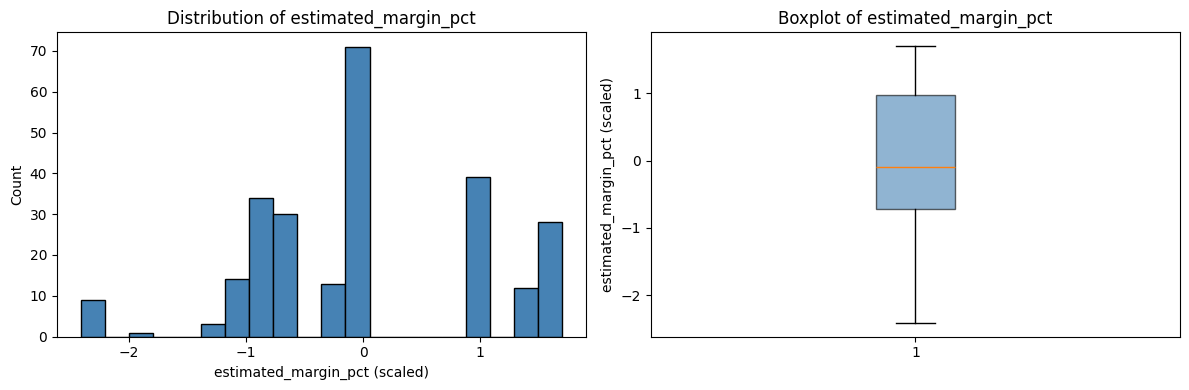

count    254.000
mean       0.000
std        1.002
min       -2.410
25%       -0.717
50%       -0.102
75%        0.972
max        1.699
Name: estimated_margin_pct, dtype: float64


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_train['estimated_margin_pct'], bins=20, edgecolor='black', color='steelblue')
axes[0].set_xlabel('estimated_margin_pct (scaled)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of estimated_margin_pct')

axes[1].boxplot(X_train['estimated_margin_pct'].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_ylabel('estimated_margin_pct (scaled)')
axes[1].set_title('Boxplot of estimated_margin_pct')

plt.tight_layout()
plt.show()
print(X_train['estimated_margin_pct'].describe().round(3))


In [25]:
feature_1_insights = """
estimated_margin_pct measures how much of the list price is retained as gross margin
after subtracting standard production cost. It is the most direct indicator of per-unit
profitability risk in this dataset.

Pre-scaling distribution (254 products): range 23%–63%, mean 46%, median 45%, std 10%.
The distribution is approximately symmetric — no strong skew — meaning StandardScaler
preserves the shape well and the scaled version is centred at zero with unit variance.

12 products sit below the 30% margin threshold, a level that typically signals cost
pressure or below-market pricing. At the other end, 117 products exceed 45% margin,
indicating healthy pricing power or low production costs. No product has a negative
margin in the training set, so there are no cost-exceeds-price cases to flag.

The 10-percentage-point standard deviation is wide enough to support meaningful cluster
separation: a cluster centred around 30–35% margin has materially different pricing-risk
characteristics than one centred around 55–60%. Distinguishing these groups is a primary
objective of the use case.
"""


In [26]:
# Do not modify this code
print_tile(size="h3", key='feature_1_insights', value=feature_1_insights)

### C.6 Explore Feature of Interest `latest_list_price`


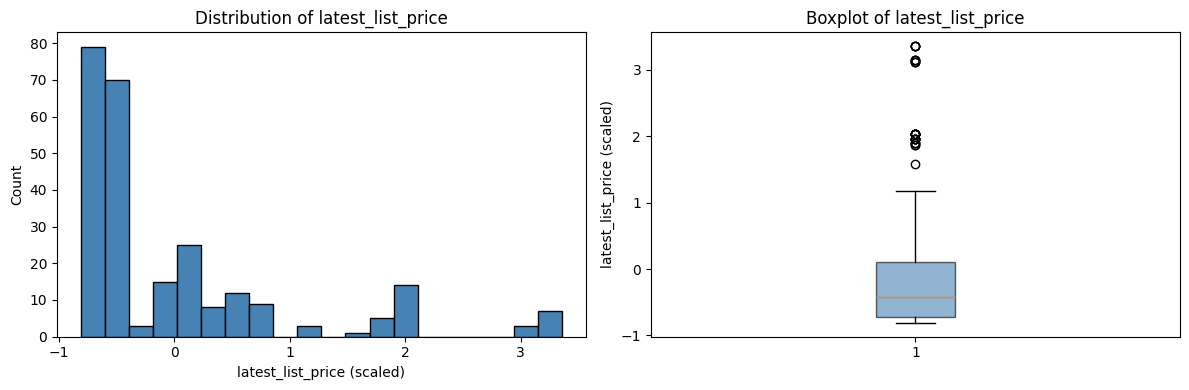

count    254.000
mean       0.000
std        1.002
min       -0.809
25%       -0.715
50%       -0.419
75%        0.101
max        3.358
Name: latest_list_price, dtype: float64


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_train['latest_list_price'], bins=20, edgecolor='black', color='steelblue')
axes[0].set_xlabel('latest_list_price (scaled)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of latest_list_price')

axes[1].boxplot(X_train['latest_list_price'].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_ylabel('latest_list_price (scaled)')
axes[1].set_title('Boxplot of latest_list_price')

plt.tight_layout()
plt.show()
print(X_train['latest_list_price'].describe().round(3))


In [28]:
feature_2_insights = """
latest_list_price is the most recent catalogue price for each product. It captures the
price tier a product occupies and, in combination with standard cost, drives the margin
calculation directly.

Pre-scaling distribution (254 products): range \$2.29–\$3,578.27, median \$337, mean \$749,
std \$910. The distribution is heavily right-skewed — most products cluster in the low-to-mid
price range while a minority of high-value products extend the tail. StandardScaler does not
remove this skew; the scaled distribution retains the same shape.

Product tiers visible in the raw data: 68 products below \$100 (consumables and accessories),
91 between \$100–\$1,000 (mid-range), and 62 above \$1,000 (premium / high-end). These tiers
correspond closely to product line composition — S and T lines tend to concentrate at lower
price points, while R-line products span a wider range.

Price tier is a strong structural differentiator for clustering: high-price products typically
face different inventory risk, different discount pressure, and different margin dynamics than
low-price products. Clusters that separate on price will therefore tend to be interpretable
in business terms without additional labelling.
"""


In [29]:
# Do not modify this code
print_tile(size="h3", key='feature_2_insights', value=feature_2_insights)

### C.7 Explore Feature of Interest `max_discount_pct`


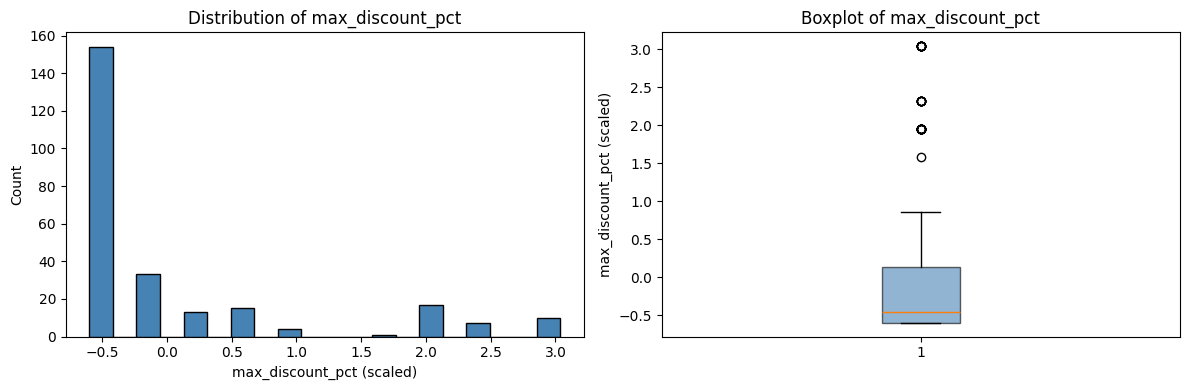

count    254.000
mean      -0.000
std        1.002
min       -0.598
25%       -0.598
50%       -0.453
75%        0.129
max        3.039
Name: max_discount_pct, dtype: float64

Products with no discount: 112


In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(X_train['max_discount_pct'], bins=20, edgecolor='black', color='steelblue')
axes[0].set_xlabel('max_discount_pct (scaled)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of max_discount_pct')

axes[1].boxplot(X_train['max_discount_pct'], vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_ylabel('max_discount_pct (scaled)')
axes[1].set_title('Boxplot of max_discount_pct')

plt.tight_layout()
plt.show()
print(X_train['max_discount_pct'].describe().round(3))
print(f"\nProducts with no discount: {(X_train['max_discount_pct'] == X_train['max_discount_pct'].min()).sum()}")


In [31]:
feature_n_insights = """
max_discount_pct records the highest promotional discount rate ever offered on a product.
It is a proxy for demand support risk: products that require heavy discounting to sustain
sales volume signal either weak pricing power, excess inventory, or both.

Pre-scaling distribution (254 products): 112 products have never been discounted
(max_discount_pct = 0); 142 carry at least some discount history. Among those, the
distribution is right-skewed — most discounts are modest (10–20%), but 34 products
have faced discounts above 30%, and 10 products carry a 50% maximum discount, which
is the highest level in the retailer's promotion schedule and typically reserved
for clearance or excess-inventory disposal.

After scaling, the distribution becomes bimodal: a large spike at the lower end
(all zero-discount products mapped to the same z-score of approximately -0.60)
and a spread of values for products with real discount history. This bimodal
structure is informative for clustering — the two groups have fundamentally different
commercial characteristics — but it also means the centroid of any cluster spanning
this feature boundary will not represent either group well. Algorithms that can
capture this discontinuity (such as hierarchical clustering) may handle it better
than those that assume smooth, convex clusters.
"""


In [32]:
# Do not modify this code
print_tile(size="h3", key='feature_n_insights', value=feature_n_insights)

### C.8 Explore Feature of Interest `class`


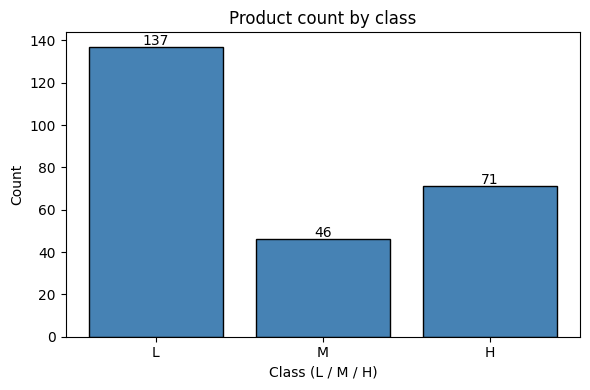

{'L': np.int64(137), 'M': np.int64(46), 'H': np.int64(71)}


In [33]:
class_labels = {X_train['class'].min(): 'L',
                sorted(X_train['class'].unique())[1]: 'M',
                X_train['class'].max(): 'H'}
counts = X_train['class'].value_counts().sort_index()
labels = [class_labels[v] for v in counts.index]
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(labels, counts.values, edgecolor='black', color='steelblue')
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 1, str(v), ha='center')
ax.set_xlabel('Class (L / M / H)')
ax.set_ylabel('Count')
ax.set_title('Product count by class')
plt.tight_layout()
plt.show()
print(dict(zip(labels, counts.values)))


In [34]:
feature_3_insights = """
class is an ordinal product quality tier encoded L=0, M=1, H=2 in SD-a and then
StandardScaled. The three scaled values map back to L (-0.854), M (0.300), H (1.453).

Distribution: L=137 (54%), H=71 (28%), M=46 (18%). The majority of sales-active
products sit at the lowest quality tier. H-class products are the second-largest
group despite being the highest complexity tier, reflecting that the portfolio
includes a substantial high-end segment alongside predominantly basic products.

H-class products typically require more days to manufacture, carry higher standard
costs, and command higher list prices, while L-class products tend to be low-cost,
high-volume items. The imbalanced distribution means class L will be the modal
value in most clusters; H-class clusters, when they emerge, are commercially distinct.
"""


In [35]:
# Do not modify this code
print_tile(size='h3', key='feature_3_insights', value=feature_3_insights)


### C.9 Explore Feature of Interest `days_to_manufacture`


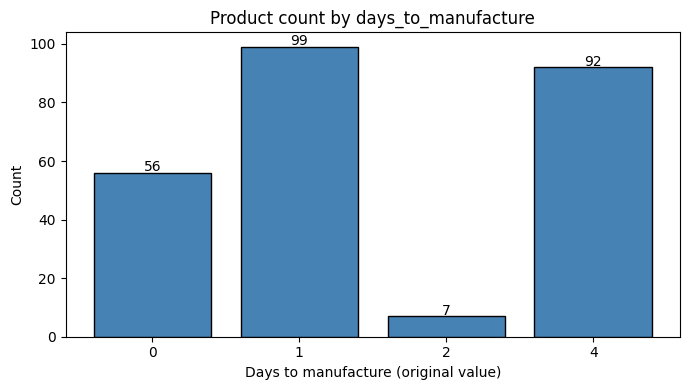

count    254.000
mean      -0.000
std        1.002
min       -1.151
25%       -0.543
50%       -0.543
75%        1.280
max        1.280
Name: days_to_manufacture, dtype: float64


In [36]:
# 4 distinct raw values: 0, 1, 2, 4 — plot as labelled bar chart
raw_vals = [0, 1, 2, 4]
raw_counts_dtm = [56, 99, 7, 92]
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([str(v) for v in raw_vals], raw_counts_dtm, edgecolor='black', color='steelblue')
for bar, v in zip(bars, raw_counts_dtm):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v), ha='center')
ax.set_xlabel('Days to manufacture (original value)')
ax.set_ylabel('Count')
ax.set_title('Product count by days_to_manufacture')
plt.tight_layout()
plt.show()
print(X_train['days_to_manufacture'].describe().round(3))


In [37]:
feature_4_insights = """
days_to_manufacture records the production lead time for each product. It is a
proxy for manufacturing complexity and indirectly reflects cost structure.

The feature takes only four distinct values: 0 (56 products — no production lead
time, typically purchased items), 1 (99 products), 2 (7 products), and 4 (92 products).
The near-absence of 2-day products makes this effectively a three-tier variable.

Products requiring 4 days (92 products, 36%) tend to be structurally more complex
and concentrate in M-line and R-line. Zero-day products are predominantly purchased
(is_manufactured=0) and carry lower standard costs. The feature was StandardScaled
as a continuous variable because the differences between levels represent real
production time differences rather than arbitrary category labels.
"""


In [38]:
# Do not modify this code
print_tile(size='h3', key='feature_4_insights', value=feature_4_insights)


### C.10 Explore Feature of Interest `is_manufactured`


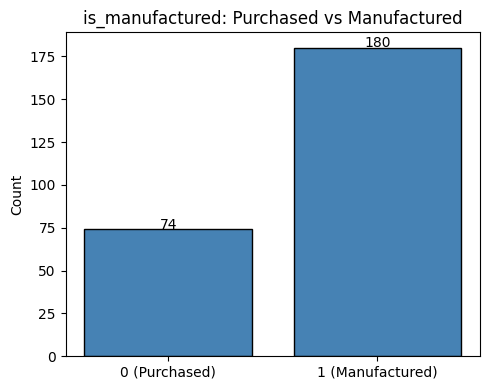

is_manufactured
1.0    180
0.0     74
Name: count, dtype: int64


In [39]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = X_train['is_manufactured'].value_counts().sort_index()
bars = ax.bar(['0 (Purchased)', '1 (Manufactured)'], [counts.get(0,0), counts.get(1,0)],
              edgecolor='black', color='steelblue')
for bar, v in zip(bars, [counts.get(0,0), counts.get(1,0)]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v), ha='center')
ax.set_ylabel('Count')
ax.set_title('is_manufactured: Purchased vs Manufactured')
plt.tight_layout()
plt.show()
print(X_train['is_manufactured'].value_counts())


In [40]:
feature_5_insights = """
is_manufactured is a binary flag: 1 = produced in-house (180 products, 71%),
0 = externally purchased (74 products, 29%).

Manufactured products carry production-driven cost structures — standard cost
reflects materials and labour, and margin depends on production efficiency and
pricing decisions. Purchased products have externally-set costs with typically
narrower cost variation and simpler margin dynamics.

This distinction is relevant for margin risk interpretation: clusters that contain
a mix of manufactured and purchased products have heterogeneous cost exposures.
Manufactured products are exposed to internal cost changes; purchased products
face supplier pricing risk. Identifying which cluster type a product belongs to
informs whether the appropriate management lever is production efficiency or
procurement negotiation.
"""


In [41]:
# Do not modify this code
print_tile(size='h3', key='feature_5_insights', value=feature_5_insights)


### C.11 Explore Feature of Interest `latest_standard_cost`


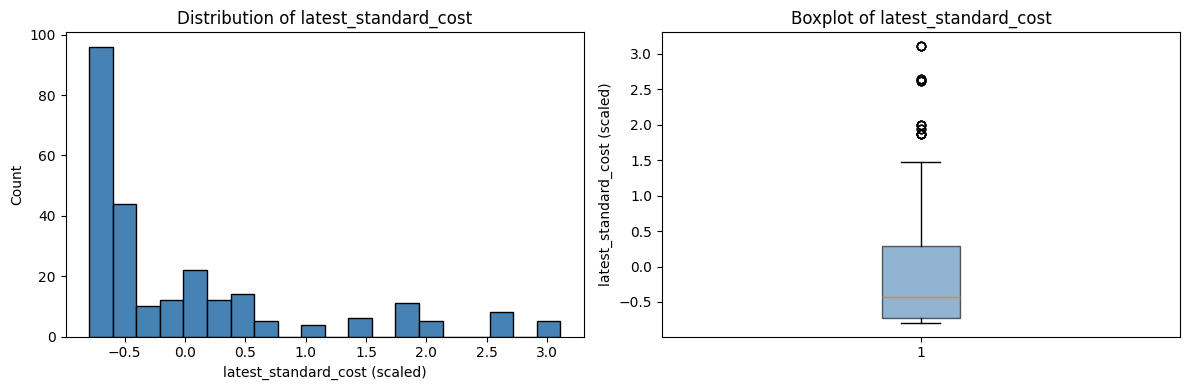

count    254.000
mean       0.000
std        1.002
min       -0.793
25%       -0.730
50%       -0.436
75%        0.287
max        3.110
Name: latest_standard_cost, dtype: float64


In [42]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_train['latest_standard_cost'], bins=20, edgecolor='black', color='steelblue')
axes[0].set_xlabel('latest_standard_cost (scaled)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of latest_standard_cost')
axes[1].boxplot(X_train['latest_standard_cost'].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_ylabel('latest_standard_cost (scaled)')
axes[1].set_title('Boxplot of latest_standard_cost')
plt.tight_layout()
plt.show()
print(X_train['latest_standard_cost'].describe().round(3))


In [43]:
feature_6_insights = """
latest_standard_cost is the most recent production cost. Together with
latest_list_price it is one of the two inputs to estimated_margin_pct.

Pre-scaling distribution: range \$0.86–\$2,171.29, median \$200, mean \$442, std \$557.
Heavily right-skewed — most products have relatively low production costs while a
minority of complex, high-value products carry very high costs.

latest_standard_cost is correlated with latest_list_price (r=0.90 in SD-a E.4) but
was retained because cost structure adds information beyond price level: two products
with the same list price can have very different cost bases and therefore very
different margin profiles. The correlation did not meet the 0.85 drop threshold on
the pair-wise check, and cost is directionally distinct from price in the margin
calculation.
"""


In [44]:
# Do not modify this code
print_tile(size='h3', key='feature_6_insights', value=feature_6_insights)


### C.12 Explore Feature of Interest `cost_range`


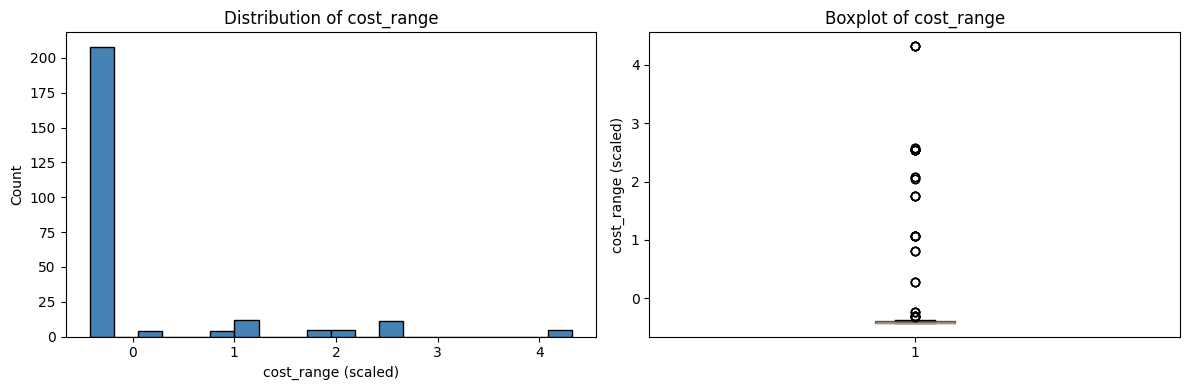

count    254.000
mean       0.000
std        1.002
min       -0.422
25%       -0.422
50%       -0.422
75%       -0.393
max        4.323
Name: cost_range, dtype: float64
Products with zero cost history change: 187


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_train['cost_range'], bins=20, edgecolor='black', color='steelblue')
axes[0].set_xlabel('cost_range (scaled)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of cost_range')
axes[1].boxplot(X_train['cost_range'].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_ylabel('cost_range (scaled)')
axes[1].set_title('Boxplot of cost_range')
plt.tight_layout()
plt.show()
print(X_train['cost_range'].describe().round(3))
print(f'Products with zero cost history change: {(X_train["cost_range"] == X_train["cost_range"].min()).sum()}')


In [46]:
feature_7_insights = """
cost_range is the difference between the highest and lowest historical standard cost
recorded for each product. It measures cost volatility over the product lifetime.

Pre-scaling: 187 products (74%) have a cost range of \$0 — their production cost
has never changed. Only 67 products show any cost variation, with a maximum range
of \$234.26. The spike at zero dominates the scaled distribution.

A non-zero cost_range indicates that a product's production cost has been revised
at least once — due to input cost changes, process changes, or revaluation. Products
with large cost ranges have experienced significant cost instability; if list prices
did not adjust proportionally, margin will have compressed. Like max_discount_pct,
this feature has a bimodal structure after scaling: a large spike at the minimum
(zero-change products) and a spread of values for the volatile minority.
"""


In [47]:
# Do not modify this code
print_tile(size='h3', key='feature_7_insights', value=feature_7_insights)


### C.13 Explore Feature of Interest `price_range`


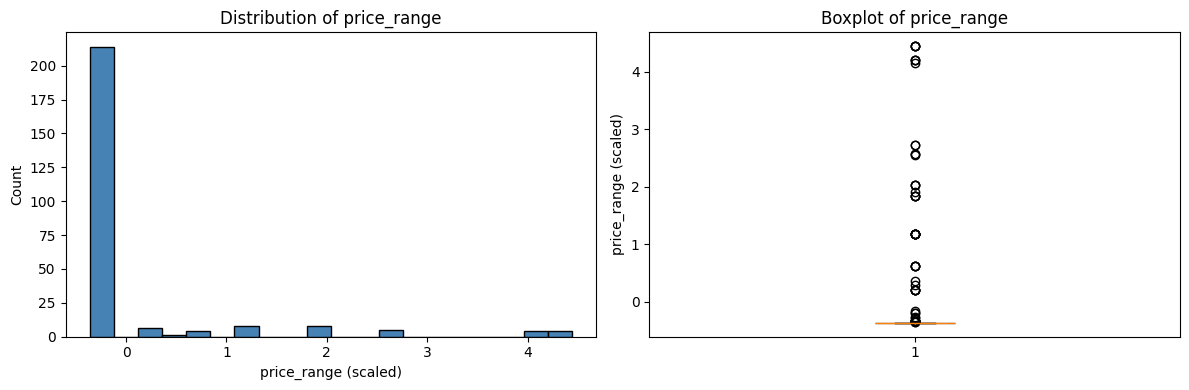

count    254.000
mean       0.000
std        1.002
min       -0.363
25%       -0.363
50%       -0.363
75%       -0.363
max        4.444
Name: price_range, dtype: float64
Products with no price change: 200


In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_train['price_range'], bins=20, edgecolor='black', color='steelblue')
axes[0].set_xlabel('price_range (scaled)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of price_range')
axes[1].boxplot(X_train['price_range'].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_ylabel('price_range (scaled)')
axes[1].set_title('Boxplot of price_range')
plt.tight_layout()
plt.show()
print(X_train['price_range'].describe().round(3))
print(f'Products with no price change: {(X_train["price_range"] == X_train["price_range"].min()).sum()}')


In [49]:
feature_8_insights = """
price_range is the difference between the highest and lowest historical list price
recorded for each product. It measures price stability over the product lifetime.

Pre-scaling: 200 products in X_train sit at the minimum scaled value (corresponding
to a \$0 price range), meaning their list price has never changed. Products with
non-zero price_range have been repriced at least once, with a maximum range of \$261.79.

Price stability signals steady-state demand with predictable margin dynamics.
A high price_range can indicate promotional pricing (price cut and restored) or
a permanent reprice under market pressure. Products with both high price_range and
high max_discount_pct have been subjected to pricing pressure from multiple directions
simultaneously — the strongest compound margin-risk signal available in this dataset.
"""


In [50]:
# Do not modify this code
print_tile(size='h3', key='feature_8_insights', value=feature_8_insights)


### C.14 Explore Feature of Interest `total_quantity_sold`


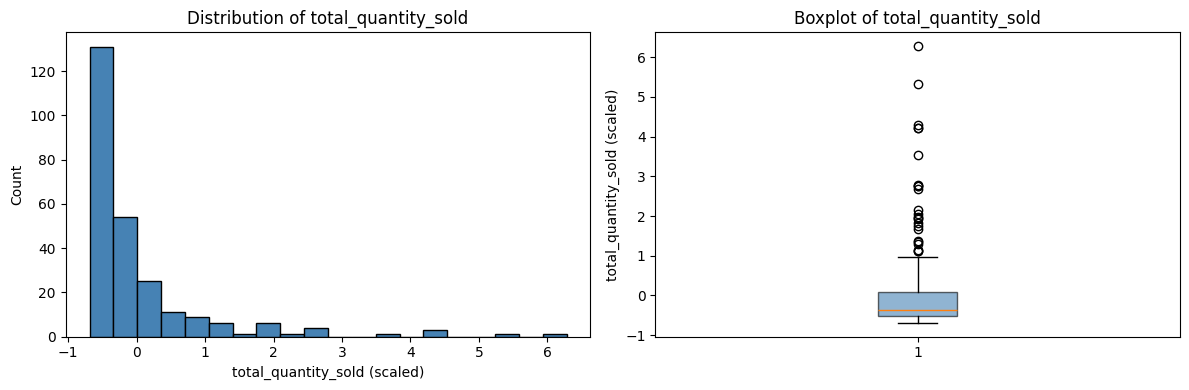

count    254.000
mean       0.000
std        1.002
min       -0.689
25%       -0.526
50%       -0.366
75%        0.085
max        6.281
Name: total_quantity_sold, dtype: float64


In [51]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(X_train['total_quantity_sold'], bins=20, edgecolor='black', color='steelblue')
axes[0].set_xlabel('total_quantity_sold (scaled)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of total_quantity_sold')
axes[1].boxplot(X_train['total_quantity_sold'].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
axes[1].set_ylabel('total_quantity_sold (scaled)')
axes[1].set_title('Boxplot of total_quantity_sold')
plt.tight_layout()
plt.show()
print(X_train['total_quantity_sold'].describe().round(3))


In [52]:
feature_9_insights = """
total_quantity_sold is the cumulative units sold across all transactions for each
product. It measures demand volume over the full sales history.

Pre-scaling distribution: range 1–2,837 units, median 132, mean 281, std 408.
Heavily right-skewed — a small number of products account for very high cumulative
volumes while the majority sit well below the mean.

Volume is critical for margin-risk prioritisation: high-volume products with thin
margins carry the greatest aggregate financial exposure — small per-unit margin
changes multiply across a large quantity base. Low-volume products with thin margins
are less impactful in absolute terms but may signal early demand problems. A cluster
combining high volume with high estimated_margin_pct identifies commercial anchors —
products that should be protected from discount pressure.
"""


In [53]:
# Do not modify this code
print_tile(size='h3', key='feature_9_insights', value=feature_9_insights)


### C.15 Explore Feature of Interest `num_discount_offers`


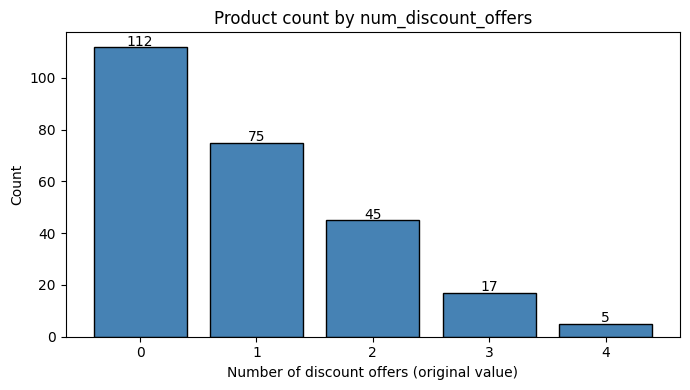

count    254.000
mean      -0.000
std        1.002
min       -0.903
25%       -0.903
50%        0.069
75%        1.041
max        2.986
Name: num_discount_offers, dtype: float64


In [54]:
# 5 distinct raw values: 0–4 — plot as labelled bar chart
raw_counts_ndo = {0: 112, 1: 75, 2: 45, 3: 17, 4: 5}
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([str(k) for k in sorted(raw_counts_ndo)],
              [raw_counts_ndo[k] for k in sorted(raw_counts_ndo)],
              edgecolor='black', color='steelblue')
for bar, v in zip(bars, [raw_counts_ndo[k] for k in sorted(raw_counts_ndo)]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v), ha='center')
ax.set_xlabel('Number of discount offers (original value)')
ax.set_ylabel('Count')
ax.set_title('Product count by num_discount_offers')
plt.tight_layout()
plt.show()
print(X_train['num_discount_offers'].describe().round(3))


In [55]:
feature_10_insights = """
num_discount_offers counts the distinct real promotional offers ever associated
with each product (No Discount placeholders excluded).

Distribution: 112 products (44%) have never been included in a real discount offer;
75 have been included in exactly 1; 45 in 2; 17 in 3; 5 in 4. The feature effectively
takes only 5 unique values, making it more categorical than continuous in practice.

Together with max_discount_pct and has_volume_discount, this feature forms the
promotion exposure profile. A high num_discount_offers combined with high
max_discount_pct indicates a product that has been repeatedly and deeply discounted —
the clearest signal of sustained demand support risk in this dataset.
"""


In [56]:
# Do not modify this code
print_tile(size='h3', key='feature_10_insights', value=feature_10_insights)


### C.16 Explore Feature of Interest `has_volume_discount`


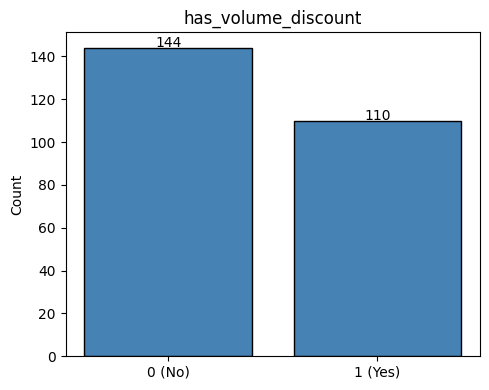

has_volume_discount
0.0    144
1.0    110
Name: count, dtype: int64


In [57]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = X_train['has_volume_discount'].value_counts().sort_index()
bars = ax.bar(['0 (No)', '1 (Yes)'], [counts.get(0,0), counts.get(1,0)],
              edgecolor='black', color='steelblue')
for bar, v in zip(bars, [counts.get(0,0), counts.get(1,0)]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v), ha='center')
ax.set_ylabel('Count')
ax.set_title('has_volume_discount')
plt.tight_layout()
plt.show()
print(X_train['has_volume_discount'].value_counts())


In [58]:
feature_11_insights = """
has_volume_discount is a binary flag: 1 = product has been in a volume discount
offer (110 products, 43%), 0 = it has not (144 products, 57%).

Volume discounts are a deliberate pricing strategy — they trade reduced per-unit
margin for higher throughput, targeting bulk buyers. This is structurally different
from clearance discounting.

Products with has_volume_discount=1 and strong total_quantity_sold represent a
volume-strategy cluster: intentional margin trade-off for scale. Products with
has_volume_discount=1 but low total_quantity_sold may indicate the discount
failed to generate the intended uplift — a potential margin-risk signal if the
discounts were also deep (high max_discount_pct).
"""


In [59]:
# Do not modify this code
print_tile(size='h3', key='feature_11_insights', value=feature_11_insights)


### C.17 Explore Feature of Interest `product_line_M`


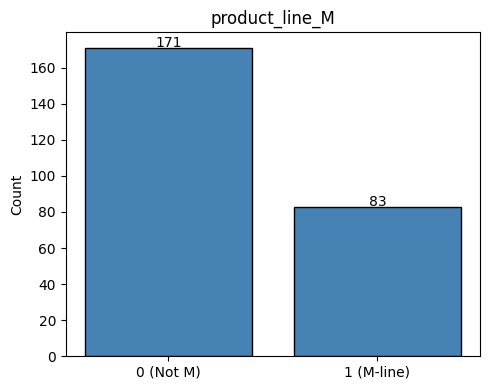

product_line_M
0    171
1     83
Name: count, dtype: int64


In [60]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = X_train['product_line_M'].value_counts().sort_index()
bars = ax.bar(['0 (Not M)', '1 (M-line)'], [counts.get(0,0), counts.get(1,0)],
              edgecolor='black', color='steelblue')
for bar, v in zip(bars, [counts.get(0,0), counts.get(1,0)]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v), ha='center')
ax.set_ylabel('Count')
ax.set_title('product_line_M')
plt.tight_layout()
plt.show()
print(X_train['product_line_M'].value_counts())


In [61]:
feature_12_insights = """
product_line_M is the one-hot indicator for the Mountain line. 83 products (33%)
are Mountain; 171 are not.

Mountain products cover off-road cycling equipment with higher manufacturing
complexity, longer production times, and higher standard costs. They are
predominantly in-house manufactured and skew toward higher class tiers.
As a one-hot feature, product_line_M contributes a binary distance signal:
two products are either both M-line (distance 0) or one is M-line and the
other is not (distance 1) on this dimension.
"""


In [62]:
# Do not modify this code
print_tile(size='h3', key='feature_12_insights', value=feature_12_insights)


### C.18 Explore Feature of Interest `product_line_R`


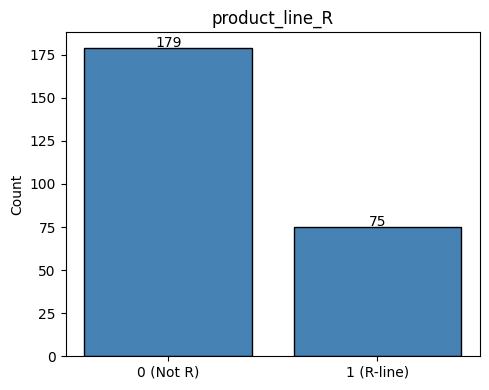

product_line_R
0    179
1     75
Name: count, dtype: int64


In [63]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = X_train['product_line_R'].value_counts().sort_index()
bars = ax.bar(['0 (Not R)', '1 (R-line)'], [counts.get(0,0), counts.get(1,0)],
              edgecolor='black', color='steelblue')
for bar, v in zip(bars, [counts.get(0,0), counts.get(1,0)]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v), ha='center')
ax.set_ylabel('Count')
ax.set_title('product_line_R')
plt.tight_layout()
plt.show()
print(X_train['product_line_R'].value_counts())


In [64]:
feature_13_insights = """
product_line_R is the one-hot indicator for the Road line. 75 products (30%)
are Road; 179 are not.

Road products span the widest list price range in the portfolio — from affordable
entry-level to premium performance models. R-line products may therefore appear in
multiple clusters based on price tier and margin profile, rather than forming a
single cohesive cluster on product line alone. R-line and M-line together account
for 63% of the 254 training products.
"""


In [65]:
# Do not modify this code
print_tile(size='h3', key='feature_13_insights', value=feature_13_insights)


### C.19 Explore Feature of Interest `product_line_S`


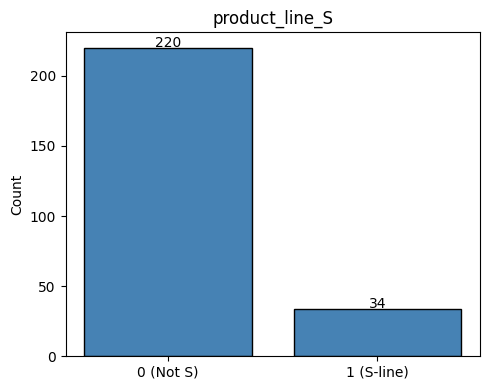

product_line_S
0    220
1     34
Name: count, dtype: int64


In [66]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = X_train['product_line_S'].value_counts().sort_index()
bars = ax.bar(['0 (Not S)', '1 (S-line)'], [counts.get(0,0), counts.get(1,0)],
              edgecolor='black', color='steelblue')
for bar, v in zip(bars, [counts.get(0,0), counts.get(1,0)]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v), ha='center')
ax.set_ylabel('Count')
ax.set_title('product_line_S')
plt.tight_layout()
plt.show()
print(X_train['product_line_S'].value_counts())


In [67]:
feature_14_insights = """
product_line_S is the one-hot indicator for the Specialty line. 34 products (13%)
are Specialty; 220 are not.

Specialty products are niche items (accessories, clothing) with simple manufacturing
profiles — predominantly purchased and carrying lower standard costs. The lower
prevalence means S-line membership is less likely to be a primary cluster differentiator,
but may contribute to defining a low-cost, low-price accessory cluster.
"""


In [68]:
# Do not modify this code
print_tile(size='h3', key='feature_14_insights', value=feature_14_insights)


### C.20 Explore Feature of Interest `product_line_T`


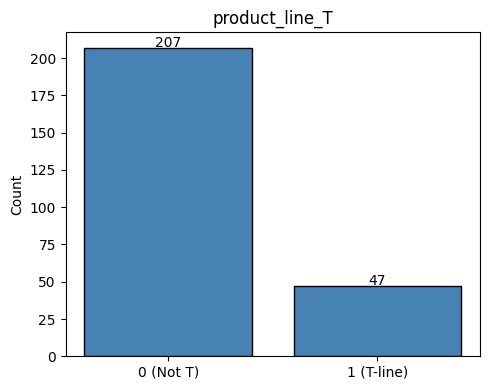

product_line_T
0    207
1     47
Name: count, dtype: int64


In [69]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = X_train['product_line_T'].value_counts().sort_index()
bars = ax.bar(['0 (Not T)', '1 (T-line)'], [counts.get(0,0), counts.get(1,0)],
              edgecolor='black', color='steelblue')
for bar, v in zip(bars, [counts.get(0,0), counts.get(1,0)]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v), ha='center')
ax.set_ylabel('Count')
ax.set_title('product_line_T')
plt.tight_layout()
plt.show()
print(X_train['product_line_T'].value_counts())


In [70]:
feature_15_insights = """
product_line_T is the one-hot indicator for the Touring line. 47 products (19%)
are Touring; 207 are not.

Touring products are designed for endurance riding, sitting between Mountain and
Specialty in price and complexity. T-line products tend to sit in the mid-price
range with moderate manufacturing lead times and more stable margin profiles,
as the touring segment attracts less aggressive promotional pricing than Mountain.
"""


In [71]:
# Do not modify this code
print_tile(size='h3', key='feature_15_insights', value=feature_15_insights)


### C.21 Explore Feature of Interest `product_line_Unknown`


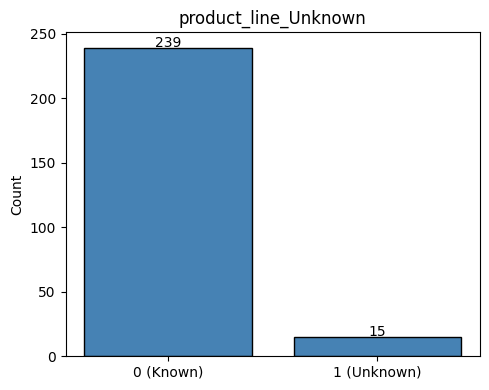

product_line_Unknown
0    239
1     15
Name: count, dtype: int64


In [72]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = X_train['product_line_Unknown'].value_counts().sort_index()
bars = ax.bar(['0 (Known)', '1 (Unknown)'], [counts.get(0,0), counts.get(1,0)],
              edgecolor='black', color='steelblue')
for bar, v in zip(bars, [counts.get(0,0), counts.get(1,0)]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v), ha='center')
ax.set_ylabel('Count')
ax.set_title('product_line_Unknown')
plt.tight_layout()
plt.show()
print(X_train['product_line_Unknown'].value_counts())


In [73]:
feature_16_insights = """
product_line_Unknown is the one-hot indicator for products whose product_line
was missing and imputed as 'Unknown' in SD-a E.1. 15 products (6%) fall here.

Rather than imputing a modal product line, the Unknown category preserves the
data gap as a distinct value, allowing the algorithm to determine whether these
15 products share characteristics with a named line or form a distinct group.
With 6% prevalence, this group sits just above the 5.5% variance threshold
that removed style_M (~2%), and was therefore retained.
"""


In [74]:
# Do not modify this code
print_tile(size='h3', key='feature_16_insights', value=feature_16_insights)


### C.22 Explore Feature of Interest `style_U`


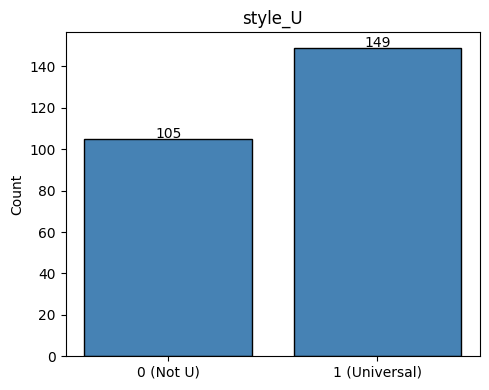

style_U
1    149
0    105
Name: count, dtype: int64


In [75]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = X_train['style_U'].value_counts().sort_index()
bars = ax.bar(['0 (Not U)', '1 (Universal)'], [counts.get(0,0), counts.get(1,0)],
              edgecolor='black', color='steelblue')
for bar, v in zip(bars, [counts.get(0,0), counts.get(1,0)]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v), ha='center')
ax.set_ylabel('Count')
ax.set_title('style_U')
plt.tight_layout()
plt.show()
print(X_train['style_U'].value_counts())


In [76]:
feature_17_insights = """
style_U is the one-hot indicator for Universal style. 149 products (59%) have
Universal style; 105 do not.

Universal-style products have no gender-specific sizing, representing accessories,
components, and equipment that apply to all riders. This is the dominant style
category, reflecting that most of the portfolio consists of components rather
than apparel. Given 59% prevalence, style_U will be the modal style in many
clusters; style-driven cluster separation is more likely to be driven by other
commercial features.
"""


In [77]:
# Do not modify this code
print_tile(size='h3', key='feature_17_insights', value=feature_17_insights)


### C.23 Explore Feature of Interest `style_Unknown`


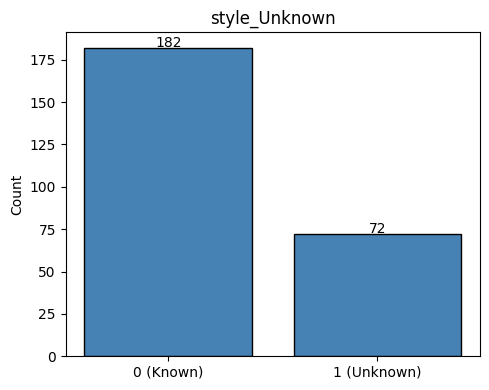

style_Unknown
0    182
1     72
Name: count, dtype: int64


In [78]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = X_train['style_Unknown'].value_counts().sort_index()
bars = ax.bar(['0 (Known)', '1 (Unknown)'], [counts.get(0,0), counts.get(1,0)],
              edgecolor='black', color='steelblue')
for bar, v in zip(bars, [counts.get(0,0), counts.get(1,0)]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v), ha='center')
ax.set_ylabel('Count')
ax.set_title('style_Unknown')
plt.tight_layout()
plt.show()
print(X_train['style_Unknown'].value_counts())


In [79]:
feature_18_insights = """
style_Unknown is the one-hot indicator for products whose style was missing and
imputed as 'Unknown' in SD-a E.1. 72 products (28%) fall here.

Unknown style is the second-largest style group after Universal. Products with
Unknown style are predominantly components and accessories where style is not a
relevant attribute, which explains the high rate of missing values. With 28%
prevalence, this group is large enough to potentially anchor its own cluster
or appear prominently across multiple clusters.
"""


In [80]:
# Do not modify this code
print_tile(size='h3', key='feature_18_insights', value=feature_18_insights)


### C.24 Explore Feature of Interest `style_W`


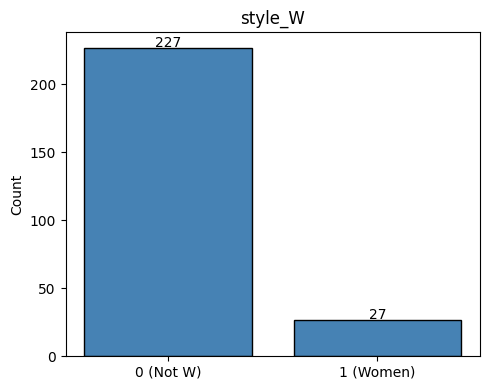

style_W
0    227
1     27
Name: count, dtype: int64


In [81]:
fig, ax = plt.subplots(figsize=(5, 4))
counts = X_train['style_W'].value_counts().sort_index()
bars = ax.bar(['0 (Not W)', '1 (Women)'], [counts.get(0,0), counts.get(1,0)],
              edgecolor='black', color='steelblue')
for bar, v in zip(bars, [counts.get(0,0), counts.get(1,0)]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5, str(v), ha='center')
ax.set_ylabel('Count')
ax.set_title('style_W')
plt.tight_layout()
plt.show()
print(X_train['style_W'].value_counts())


In [82]:
feature_19_insights = """
style_W is the one-hot indicator for Women-specific style. 27 products (11%)
have Women style; 227 do not.

Women-specific products are mostly apparel and accessories (jerseys, shorts,
gloves) with relatively low list prices and simple manufacturing profiles.
With 11% prevalence, style_W is above the variance threshold that removed
style_M (~2%) and was retained. It represents a minority signal — any cluster
where W-style products concentrate will be a relatively small group but
commercially distinct (low price, low cost, apparel-focused).
"""


In [83]:
# Do not modify this code
print_tile(size='h3', key='feature_19_insights', value=feature_19_insights)


---
## D. Feature Selection


In [84]:
features_list = [
    # Structural / product attributes
    'class', 'days_to_manufacture', 'is_manufactured',
    # Cost and pricing
    'latest_standard_cost', 'cost_range', 'latest_list_price', 'price_range',
    # Sales behaviour
    'total_quantity_sold',
    # Promotion exposure
    'num_discount_offers', 'max_discount_pct', 'has_volume_discount',
    # Margin
    'estimated_margin_pct',
    # Product line (one-hot)
    'product_line_M', 'product_line_R', 'product_line_S', 'product_line_T', 'product_line_Unknown',
    # Style (one-hot, style_M excluded at variance filter)
    'style_U', 'style_Unknown', 'style_W',
]
print(f'Features selected: {len(features_list)}')
print(features_list)


Features selected: 20
['class', 'days_to_manufacture', 'is_manufactured', 'latest_standard_cost', 'cost_range', 'latest_list_price', 'price_range', 'total_quantity_sold', 'num_discount_offers', 'max_discount_pct', 'has_volume_discount', 'estimated_margin_pct', 'product_line_M', 'product_line_R', 'product_line_S', 'product_line_T', 'product_line_Unknown', 'style_U', 'style_Unknown', 'style_W']


In [85]:
feature_selection_explanations = """
20 features are carried forward into the clustering stage. All selection decisions
were made and documented in the data preparation notebook (SD-a); this section confirms
the final feature set that X_train.csv contains.

Features are organised across four commercial dimensions:
  - Structural / product attributes: class, days_to_manufacture, is_manufactured
  - Cost and pricing: latest_standard_cost, cost_range, latest_list_price, price_range
  - Sales behaviour: total_quantity_sold (num_orders was dropped, r=0.91 with total_quantity_sold)
  - Promotion exposure: num_discount_offers, max_discount_pct, has_volume_discount
  - Margin: estimated_margin_pct (estimated_margin dropped, r=0.99 with latest_list_price)
  - Category membership: product_line (M/R/S/T/Unknown), style (U/W/Unknown) as one-hot columns

Two exclusions applied during SD-a:
  - style_M was dropped: variance 0.023, corresponding to ~2% prevalence across 254 products.
    A category present in fewer than ~6 products cannot meaningfully anchor a cluster boundary.
  - estimated_margin and num_orders were dropped due to near-perfect correlation with
    latest_list_price (r=0.99) and total_quantity_sold (r=0.91) respectively. Retaining
    correlated features would cause those dimensions to contribute double weight to
    Euclidean distances in all three clustering algorithms.
"""


In [86]:
# Do not modify this code
print_tile(size="h3", key='feature_selection_explanations', value=feature_selection_explanations)

---
## E. Data Preparation

### E.1 Imputation (completed in SD-a)


In [87]:
# All imputation was completed in SD-a E.1.
# X_train.csv already contains the imputed values; no further action is taken here.


In [88]:
data_cleaning_1_explanations = """
All missing-value imputation was performed in the data preparation notebook (SD-a)
and the results are persisted in X_train.csv. Repeating it here would be redundant
and could produce different fill values if the source tables had changed.

The imputation strategy applied in SD-a:
  - product_line and style: missing values filled with 'Unknown', treated as a
    distinct nominal category. A separate category is preferable to imputing a
    mode because missing product_line may indicate a genuinely uncategorised product
    rather than a data entry error.
  - class: missing values filled with the mode ('M'). Class is ordinal (L/M/H) and
    'Unknown' cannot be placed on the ordinal scale, so mode imputation preserves
    the meaningful distance structure required for ordinal encoding.
  - Numeric features with nulls (latest_list_price, price_range, estimated_margin,
    estimated_margin_pct): imputed with the column median to minimise the influence
    of the right-skewed price distribution on the fill value.
"""


In [89]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_1_explanations', value=data_cleaning_1_explanations)

### E.2 Encoding (completed in SD-a)


In [90]:
# All encoding was completed in SD-a E.2.
# X_train.csv already contains encoded columns; no further action is taken here.


In [91]:
data_cleaning_2_explanations = """
All categorical encoding was performed in SD-a and is already reflected in X_train.csv.

Encoding decisions from SD-a:
  - class (L/M/H): ordinal encoding {L:0, M:1, H:2}. Class has a natural ordering
    by production complexity, so the numeric positions preserve meaningful distances.
    An L-class product is one step from M and two steps from H, which correctly
    represents their relative difference under Euclidean distance.
  - product_line and style: one-hot encoding with drop_first=False. Both are nominal
    with no natural ordering between categories. Dropping a reference category would
    create asymmetric Euclidean distances, where the dropped category appears equidistant
    from all others — a geometric distortion that penalises clustering algorithms
    that rely on centroids or pairwise distances.
"""


In [92]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_2_explanations', value=data_cleaning_2_explanations)

### E.3 Scaling and Variance / Correlation Filtering (completed in SD-a)


In [93]:
# All scaling and feature filtering was completed in SD-a E.3 and E.4.
# X_train.csv already contains scaled, filtered features; no further action is taken here.


In [94]:
data_cleaning_3_explanations = """
Scaling and feature filtering were applied in SD-a (E.3 and E.4) before X_train.csv was saved.

Scaling (SD-a E.3): StandardScaler was applied to all continuous and ordinal features.
Binary features (is_manufactured, has_volume_discount, all one-hot columns) were excluded
from scaling — their 0/1 values already occupy a bounded, comparable range, and scaling
would compress their contribution to distances rather than standardise it.

Variance filtering (SD-a E.4): style_M was removed (variance 0.023, <5.5% prevalence).
A binary feature at that prevalence level represents roughly 5 products across 254 and
cannot meaningfully anchor a cluster boundary.

Correlation filtering (SD-a E.4): estimated_margin (r=0.994 with latest_list_price) and
num_orders (r=0.913 with total_quantity_sold) were dropped. All three clustering algorithms
used here (KMeans, Mean Shift, Agglomerative) compute Euclidean distances, so retaining
highly correlated features would cause those dimensions to contribute disproportionate
weight to cluster shapes.
"""


In [95]:
# Do not modify this code
print_tile(size="h3", key='data_cleaning_3_explanations', value=data_cleaning_3_explanations)

---
## F. Feature Engineering

### F.1 Sales Behaviour Features (completed in SD-a)


In [96]:
# Sales behaviour features were engineered in SD-a D.1 and are present in X_train.csv.


In [97]:
feature_engineering_1_explanations = """
Two sales behaviour features were derived in SD-a D.1 by aggregating the sales_order_detail
table at the product level:
  - total_quantity_sold: sum of order_quantity across all transactions for a product.
    High volume with low price is a distinct commercial profile from high volume with
    high price, and this feature anchors that distinction.
  - num_orders: count of distinct sales orders containing the product. This feature was
    subsequently dropped in SD-a E.4 due to a correlation of 0.913 with total_quantity_sold;
    both features captured the same frequency signal.

No sales behaviour engineering is needed in SD-c because these features are already
present in X_train.csv at the correct aggregation level and scale.
"""


In [98]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_1_explanations', value=feature_engineering_1_explanations)

### F.2 Promotion Exposure Features (completed in SD-a)


In [99]:
# Promotion exposure features were engineered in SD-a D.2 and are present in X_train.csv.


In [100]:
feature_engineering_2_explanations = """
Three promotion exposure features were derived in SD-a D.2 by joining
special_offer_product with special_offer and aggregating at the product level.
The 'No Discount' offer type was excluded from aggregation — it acts as a
placeholder linked to all 295 bridge products and does not represent real
discount activity:
  - num_discount_offers: count of distinct promotional offers (excluding No Discount).
  - max_discount_pct: highest discount rate ever offered on the product.
  - has_volume_discount: binary flag indicating whether a volume-tier discount
    was ever applied (1) or not (0).

Products with no real discount history received 0 for all three features.
No promotion engineering is needed in SD-c.
"""


In [101]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_2_explanations', value=feature_engineering_2_explanations)

### F.3 Estimated Margin Feature (completed in SD-a)


In [102]:
# Estimated margin was derived in SD-a D.3 and is present in X_train.csv.


In [103]:
feature_engineering_n_explanations = """
estimated_margin_pct was derived in SD-a D.3 as:
    estimated_margin_pct = (latest_list_price - latest_standard_cost) / latest_list_price

This percentage form normalises for price level — a \$50 margin on a \$100 product (50%)
represents a structurally different position than a \$50 margin on a \$3,000 product (1.7%).
Using the raw margin value would conflate price-level differences with margin-efficiency
differences. The percentage form ensures the feature captures margin structure, not scale.

estimated_margin (the absolute value) was dropped in SD-a E.4 due to r=0.994 with
latest_list_price; only estimated_margin_pct is retained in the modelling dataset.

No margin engineering is needed in SD-c.
"""


In [104]:
# Do not modify this code
print_tile(size="h3", key='feature_engineering_n_explanations', value=feature_engineering_n_explanations)

---
## G. Data Preparation for Modeling

### G.1 Split Datasets


In [105]:
# Clustering is an unsupervised task — no train/validation/test split is needed.
# All 254 products are used for fitting and evaluating each model.


In [106]:
data_splitting_explanations = """
Clustering does not require a train/validation/test split.

In supervised learning, the dataset is split so the model can be evaluated on
unseen labels. In clustering, there are no labels to hold out — the model assigns
cluster memberships, and quality is measured by internal validity indices applied
to the same data used for fitting (silhouette coefficient, Calinski-Harabász index,
Davies-Bouldin index).

Using all 254 products also maximises the information available for the algorithms
to discover structure. With a dataset of this size, witholding observations would
reduce the density of the feature space and increase the risk of artefactual clusters.
"""


In [107]:
# Do not modify this code
print_tile(size="h3", key='data_splitting_explanations', value=data_splitting_explanations)

### G.2 Drop Identifier Column


In [108]:
X = X_train.drop(columns=['product_id'])
print(f'Modelling matrix X: {X.shape[0]} products × {X.shape[1]} features')
print(X.columns.tolist())


Modelling matrix X: 254 products × 20 features
['class', 'days_to_manufacture', 'is_manufactured', 'latest_standard_cost', 'cost_range', 'latest_list_price', 'price_range', 'total_quantity_sold', 'num_discount_offers', 'max_discount_pct', 'has_volume_discount', 'estimated_margin_pct', 'product_line_M', 'product_line_R', 'product_line_S', 'product_line_T', 'product_line_Unknown', 'style_U', 'style_Unknown', 'style_W']


In [109]:
data_transformation_1_explanations = """
product_id is a row identifier — it encodes no commercial signal and must be removed
before fitting any clustering algorithm. Passing an identifier column to a distance-based
algorithm would introduce arbitrary numeric differences between product IDs into the
pairwise distance calculations and corrupt cluster shapes.

product_id is retained in X_train (not dropped in SD-a) so that cluster assignments
can be joined back to the product catalogue for business interpretation. After this step,
X is the 254 × 20 modelling matrix passed to each algorithm; X_train retains the
product_id column for post-hoc lookup.
"""


In [110]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_1_explanations', value=data_transformation_1_explanations)

### G.3 No Additional Transformations Required


In [111]:
# All scaling, encoding, and filtering were performed in SD-a.
# No further transformations are applied at the modelling stage.


In [112]:
data_transformation_2_explanations = """
The modelling matrix X is ready for clustering without further transformation.
All preprocessing steps — imputation, ordinal and one-hot encoding, StandardScaling
of continuous features, variance filtering, and correlation-driven feature removal —
were completed in SD-a and are reflected in X_train.csv.

Applying additional transformations at the modelling stage would risk inconsistency
with the prepared dataset and would obscure the preparation audit trail that SD-a
provides.
"""


In [113]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_2_explanations', value=data_transformation_2_explanations)

### G.4 Verify Modelling Matrix


In [114]:
print(f'Shape: {X.shape}')
print(f'Null count: {X.isnull().sum().sum()}')
print('Feature ranges (min / max):')
print(X.agg(['min','max']).T.round(3))


Shape: (254, 20)
Null count: 0
Feature ranges (min / max):
                        min    max
class                -0.854  1.453
days_to_manufacture  -1.151  1.280
is_manufactured       0.000  1.000
latest_standard_cost -0.793  3.110
cost_range           -0.422  4.323
latest_list_price    -0.809  3.358
price_range          -0.363  4.444
total_quantity_sold  -0.689  6.281
num_discount_offers  -0.903  2.986
max_discount_pct     -0.598  3.039
has_volume_discount   0.000  1.000
estimated_margin_pct -2.410  1.699
product_line_M        0.000  1.000
product_line_R        0.000  1.000
product_line_S        0.000  1.000
product_line_T        0.000  1.000
product_line_Unknown  0.000  1.000
style_U               0.000  1.000
style_Unknown         0.000  1.000
style_W               0.000  1.000


In [115]:
data_transformation_3_explanations = """
Final verification confirms the modelling matrix is well-formed:
  - 254 rows × 20 columns — matching the expected feature count after style_M,
    estimated_margin, and num_orders were dropped in SD-a.
  - Zero null values — imputation in SD-a E.1 eliminated all missing entries.
  - Continuous and ordinal features centred near zero with unit standard deviation
    after StandardScaler; binary and one-hot columns retain 0/1 values.

The matrix is passed directly to each clustering algorithm without modification.
"""


In [116]:
# Do not modify this code
print_tile(size="h3", key='data_transformation_3_explanations', value=data_transformation_3_explanations)

In [117]:
# Clustering has no target labels — define empty placeholders so the H save cell
# runs without a NameError. X_train is the only file that will be written.
y_train = pd.DataFrame()
X_val   = pd.DataFrame()
y_val   = pd.DataFrame()
X_test  = pd.DataFrame()
y_test  = pd.DataFrame()


---
## H. Save Datasets

> Do not change this code

In [118]:
# Do not modify this code
# Save training set
try:
  X_train.to_csv(at.folder_path / 'X_train.csv', index=False)
  y_train.to_csv(at.folder_path / 'y_train.csv', index=False)

  X_val.to_csv(at.folder_path / 'X_val.csv', index=False)
  y_val.to_csv(at.folder_path / 'y_val.csv', index=False)

  X_test.to_csv(at.folder_path / 'X_test.csv', index=False)
  y_test.to_csv(at.folder_path / 'y_test.csv', index=False)
except Exception as e:
  print(e)

## I. KMeans


### I.1 Import Algorithm

In [119]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score


In [120]:
algorithm_selection_explanations = """
KMeans is selected as the primary algorithm for this use case for three reasons.

First, the feature matrix is fully numeric and standardised — all 20 features were
scaled using StandardScaler in SD-a. KMeans operates on Euclidean distance, which
is well-defined and meaningful on a standardised numeric space. Standardisation ensures that features differing by orders of magnitude — such as list price and a binary discount flag — contribute equally to the distance calculation, so clusters reflect genuine commercial similarity rather than being dominated by the scale of any single feature.

Second, KMeans produces centroid-based clusters. Each centroid is a vector of mean
feature values for that group, which translates directly into a readable product
archetype — for example, high list price, low volume, and thin margin percentage.
Category managers can interpret centroids without statistical expertise.

Third, with only 254 products, KMeans converges rapidly even with a high n_init,
making it practical to run multiple initialisations and select the best result. This also makes quarterly refresh of the segmentation feasible as the product mix, cost structure, or promotional calendar evolves.
"""


In [121]:
# Do not modify this code
print_tile(size="h3", key='algorithm_selection_explanations', value=algorithm_selection_explanations)

### I.2 Set Hyperparameters

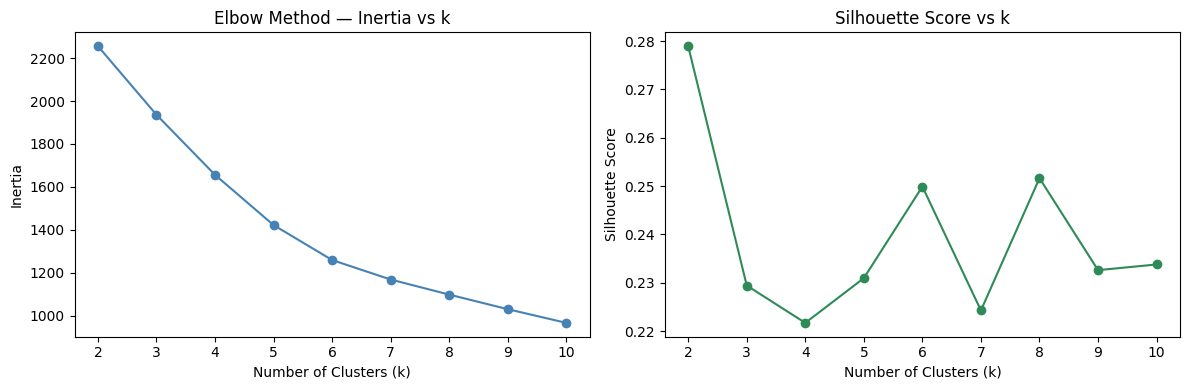

  k     Inertia        Drop  Silhouette
  2      2255.4         0.0       0.279
  3      1936.0       319.5       0.229
  4      1656.2       279.7       0.222
  5      1422.4       233.8       0.231
  6      1259.8       162.7       0.250
  7      1169.1        90.7       0.224
  8      1098.9        70.2       0.252
  9      1031.0        67.9       0.233
 10       967.2        63.8       0.234


In [122]:
# --- Elbow method: inertia across k=2..10 ---
k_range = range(2, 11)
inertia_values = []
sil_values = []

for k in k_range:
    _km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    _labels = _km.fit_predict(X)
    inertia_values.append(_km.inertia_)
    sil_values.append(silhouette_score(X, _labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(list(k_range), inertia_values, marker='o', color='steelblue')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method — Inertia vs k')

axes[1].plot(list(k_range), sil_values, marker='o', color='seagreen')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')

plt.tight_layout()
plt.show()

# Print values for inspection
print(f"{'k':>3}  {'Inertia':>10}  {'Drop':>10}  {'Silhouette':>10}")
prev = None
for k, inertia, sil in zip(k_range, inertia_values, sil_values):
    drop = (prev - inertia) if prev else 0
    print(f"{k:>3}  {inertia:>10.1f}  {drop:>10.1f}  {sil:>10.3f}")
    prev = inertia


In [123]:
# k=4 selected after inspecting the elbow and silhouette plots above
n_clusters   = 4
init         = 'k-means++'
n_init       = 20
random_state = 42
print(f'Selected: n_clusters={n_clusters}, init={init}, n_init={n_init}, random_state={random_state}')

Selected: n_clusters=4, init=k-means++, n_init=20, random_state=42


In [124]:
hyperparameters_selection_explanations = """
k=4 is selected primarily on business grounds, supported by the inertia curve.

The inertia curve shows large drops at k=3, 4, and 5 (319, 279, and 233 respectively),
indicating that each additional cluster up to k=4 captures meaningful structure in the
data. From k=6 onward the drops slow considerably (162, 90, 70), suggesting diminishing
returns from further splitting. k=4 sits at the boundary where gains are still
substantial but begin to taper.

The silhouette score peaks at k=2 (0.279) and does not favour k=4 specifically.
However, k=2 is not commercially viable — it merges fundamentally different product
profiles (low-cost efficient products and high-cost premium products) into a single
group, producing segments too broad to act on. The silhouette metric alone cannot
account for whether a segment is actionable for the business.

k=6 and k=8 also score marginally higher on silhouette (0.250 and 0.252) than k=4.
However, the inertia drops at k=6 (162.7) and k=8 (70.2) are substantially smaller
than at k=4 (279.7), confirming that those additional clusters capture progressively
less structure. The silhouette gain is also marginal — an improvement of 0.028 to
0.030 over k=4. More critically, splitting four well-defined archetypes into six or
eight sub-groups would fragment clusters whose products already share the same
margin-risk profile and require the same pricing intervention. A category manager
cannot act differently on six near-identical sub-segments; the additional granularity
adds complexity without adding decision value.

From a business perspective, four clusters map to four distinct commercial archetypes
with different margin-risk profiles and different required interventions. Fewer clusters
merge profiles that need different responses; more clusters fragment groups that share
the same risk characteristics and add no incremental decision value for a category
management team.

init='k-means++' spaces initial centroids proportionally across the feature space,
reducing the probability of a poor local minimum. n_init=20 repeats the fit 20 times
and retains the run with the lowest inertia, further stabilising the result.
random_state=42 ensures assignments are reproducible across runs.
"""

In [125]:
# Do not modify this code
print_tile(size="h3", key='hyperparameters_selection_explanations', value=hyperparameters_selection_explanations)

### I.3 Fit Model


In [126]:
km = KMeans(n_clusters=n_clusters, init=init, n_init=n_init, random_state=random_state)
km.fit(X)

X_km = X.copy()
X_km['cluster'] = km.labels_

print(f'KMeans fitted — {n_clusters} clusters')
print(X_km['cluster'].value_counts().sort_index().rename('products per cluster'))


KMeans fitted — 4 clusters
cluster
0     95
1    108
2     28
3     23
Name: products per cluster, dtype: int64


### I.4 Model Technical Performance

Silhouette: 0.222  |  Calinski-Harabasz: 66.7  |  Davies-Bouldin: 1.511


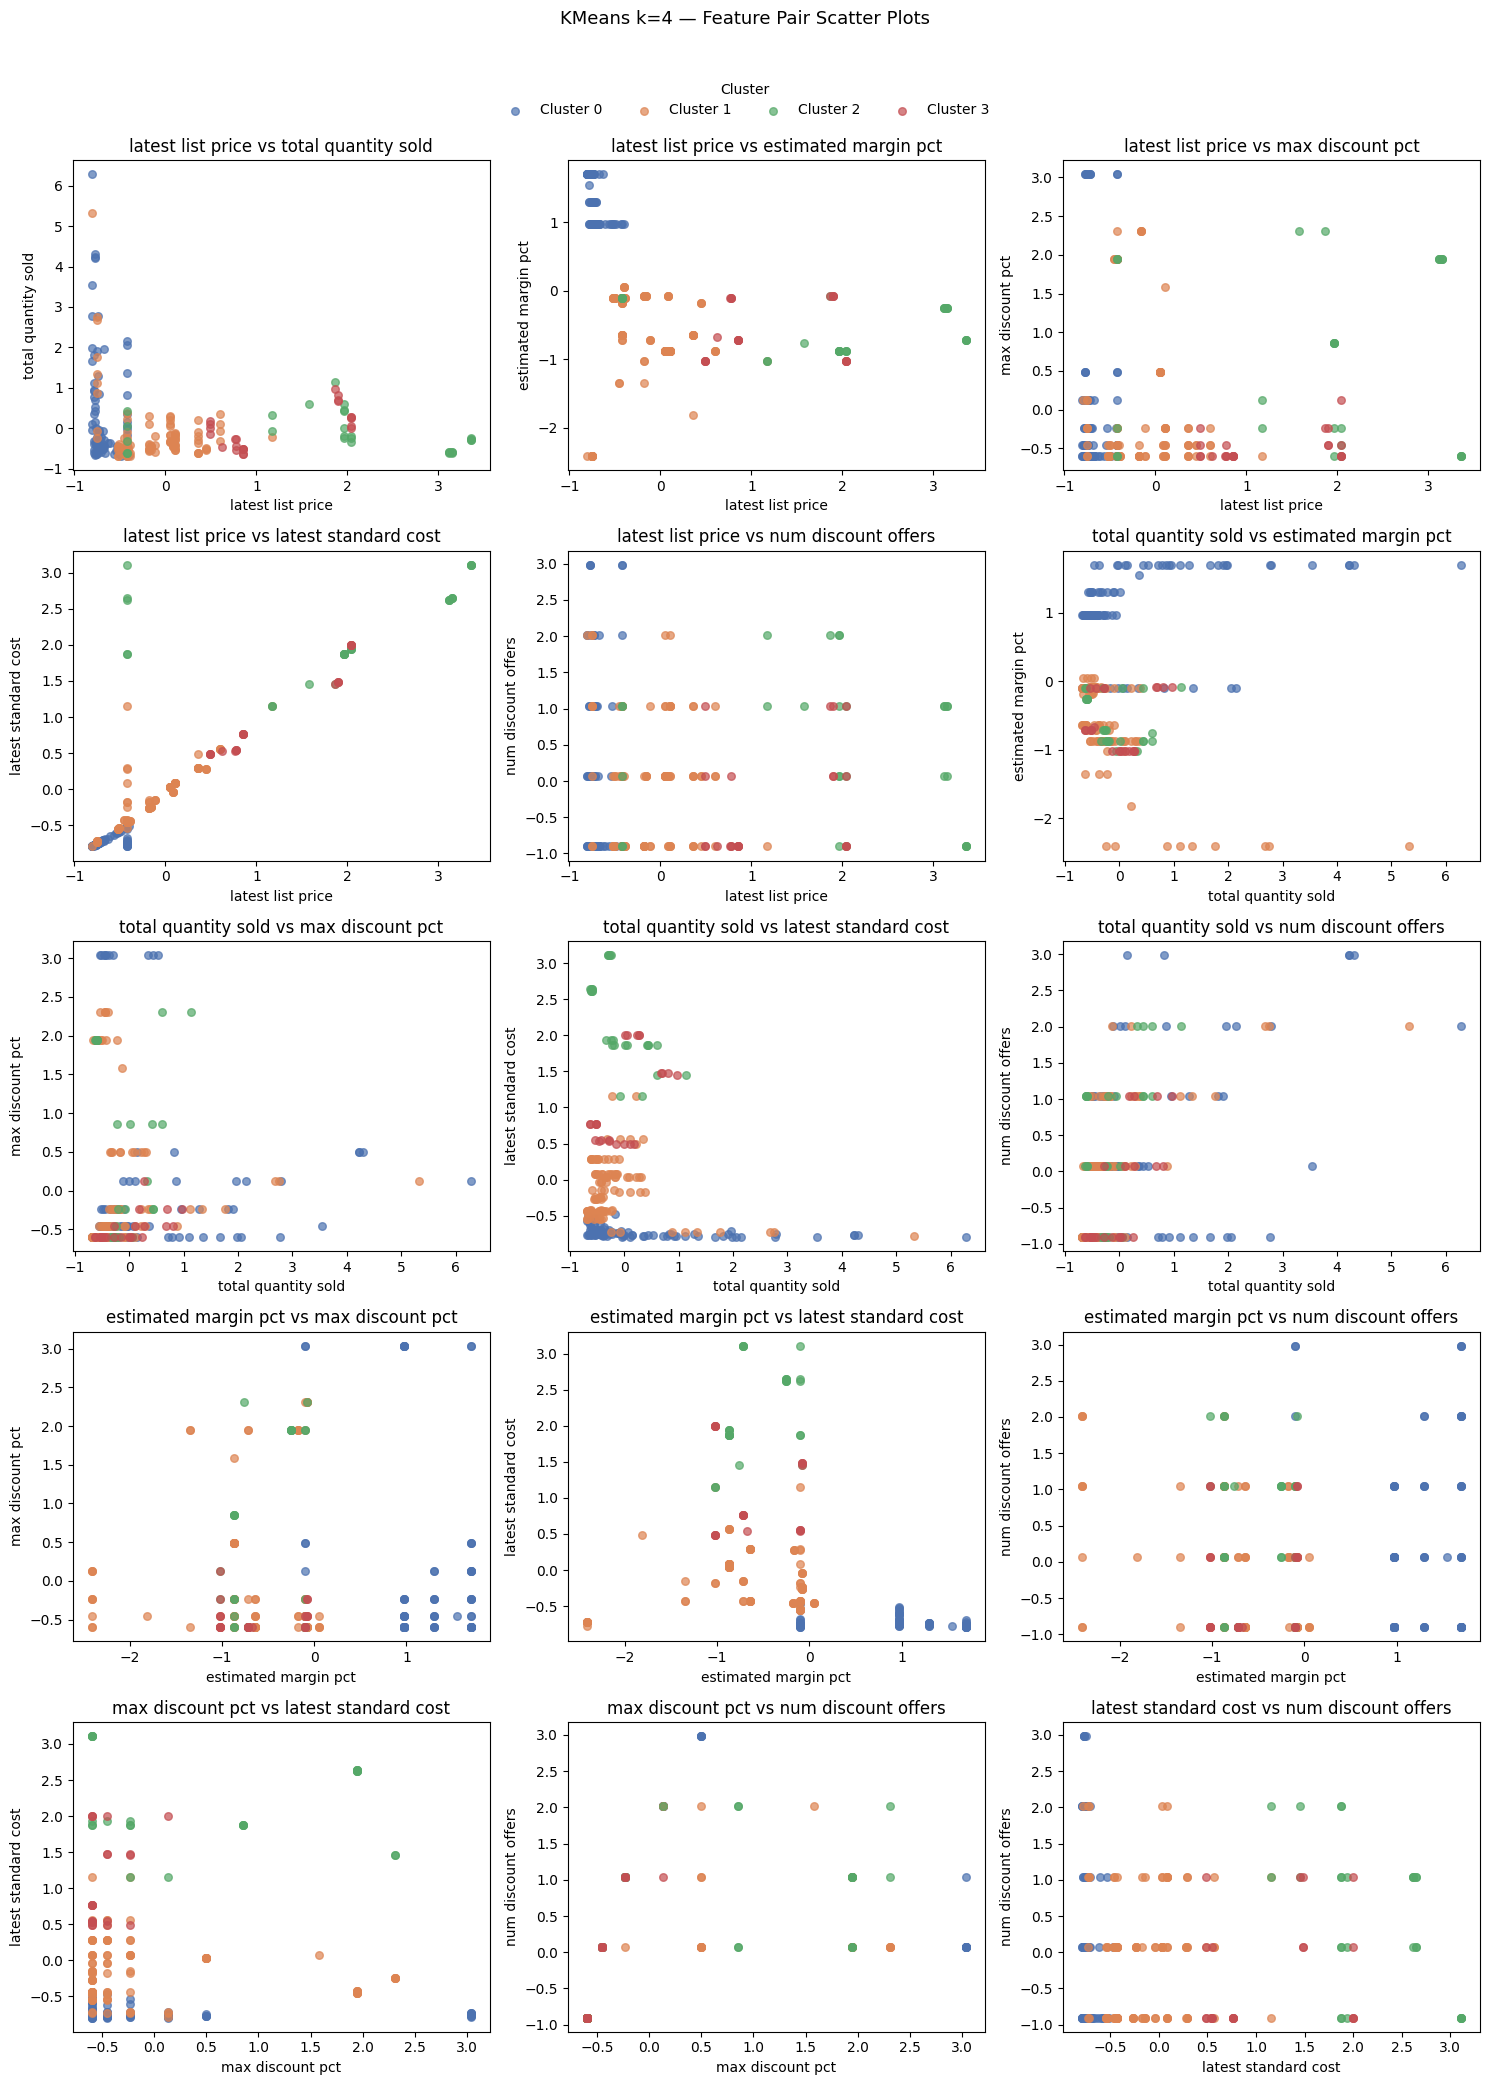


Cluster means (key features):


,latest_list_price,latest_standard_cost,estimated_margin_pct,total_quantity_sold,max_discount_pct,num_discount_offers,has_volume_discount,days_to_manufacture,n_products
cluster,,,,,,,,,
1,-0.169,-0.164,-0.643,-0.189,-0.032,-0.075,0.417,0.295,108
0,-0.666,-0.730,1.045,0.259,-0.030,0.048,0.432,-0.844,95
2,1.922,2.236,-0.558,-0.125,0.628,0.416,0.536,1.280,28
3,1.204,1.062,-0.617,-0.030,-0.488,-0.354,0.391,0.540,23


In [127]:
# --- Internal validity scores ---
sil  = silhouette_score(X, km.labels_)
ch   = calinski_harabasz_score(X, km.labels_)
db   = davies_bouldin_score(X, km.labels_)
print(f'Silhouette: {sil:.3f}  |  Calinski-Harabasz: {ch:.1f}  |  Davies-Bouldin: {db:.3f}')

# --- Pairs grid: key commercial features coloured by cluster ---
key_features = [
    'latest_list_price', 'total_quantity_sold',
    'estimated_margin_pct', 'max_discount_pct',
    'latest_standard_cost', 'num_discount_offers'
]
pairs = [(key_features[i], key_features[j])
         for i in range(len(key_features))
         for j in range(i + 1, len(key_features))]

ncols = 3
nrows = -(-len(pairs) // ncols)  # ceiling division
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

for idx, (a, b) in enumerate(pairs):
    ax = axes[idx]
    for cl in sorted(X_km['cluster'].unique()):
        mask = X_km['cluster'] == cl
        ax.scatter(X_km.loc[mask, a], X_km.loc[mask, b],
                   s=30, alpha=0.7, color=colors[cl], label=f'Cluster {cl}')
    ax.set_xlabel(a.replace('_', ' '))
    ax.set_ylabel(b.replace('_', ' '))
    ax.set_title(f'{a.replace("_", " ")} vs {b.replace("_", " ")}')

for idx in range(len(pairs), len(axes)):
    fig.delaxes(axes[idx])

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Cluster', loc='upper center',
           ncol=4, frameon=False, bbox_to_anchor=(0.5, 1.01))
plt.suptitle('KMeans k=4 — Feature Pair Scatter Plots', y=1.04, fontsize=13)
plt.tight_layout()
plt.show()

# --- Cluster means table ---
summary_cols = [
    'latest_list_price', 'latest_standard_cost', 'estimated_margin_pct',
    'total_quantity_sold', 'max_discount_pct', 'num_discount_offers',
    'has_volume_discount', 'days_to_manufacture'
]
sizes = X_km.groupby('cluster').size().rename('n_products')
cluster_means = (
    X_km.groupby('cluster')[summary_cols]
        .mean()
        .round(3)
        .join(sizes)
        .sort_values('n_products', ascending=False)
)
print('\nCluster means (key features):')
cluster_means


In [128]:
model_performance_explanations = """
KMeans k=4 achieved a Silhouette score of 0.222, Calinski-Harabasz of 66.7, and
Davies-Bouldin of 1.511. The silhouette score indicates moderate within-cluster
cohesion — products are more similar to their own cluster than to neighbouring
clusters, though the separation is not strong. The CH score of 66.7 is the highest
across all three algorithms, confirming that KMeans produces the most well-defined
and well-separated groups relative to their internal compactness. For portfolio planning purposes, these scores indicate that the four archetypes are commercially distinguishable enough to support differentiated pricing strategies — a category manager applying different discount rules to each segment is unlikely to encounter overlapping or contradictory interventions across the clusters.

The scatter plots show clear separation on the price-volume and margin-discount
axes — the two dimensions most relevant to margin-risk assessment. Distinct
groupings are visible across multiple feature pairs, confirming the clusters
reflect genuine commercial structure rather than an artefact of a single feature.

The cluster means table confirms structural differences between all four groups:
clusters diverge on list price, standard cost, estimated margin percentage, total
quantity sold, and maximum discount applied. Cluster sizes of 95, 108, 28, and 23
products are all commercially actionable — no cluster is trivially small or so
large that it encompasses the entire portfolio without meaningful discrimination.
"""

In [129]:
# Do not modify this code
print_tile(size="h3", key='model_performance_explanations', value=model_performance_explanations)

Per-product silhouette breakdown (n=254):
  Firmly assigned  (>= 0.3): 48
  Moderate       (0.1-0.3): 179
  Borderline     (0.0-0.1): 26
  Potentially misassigned (<0.0): 1

Mean silhouette: 0.222
Min: -0.000  |  Max: 0.499


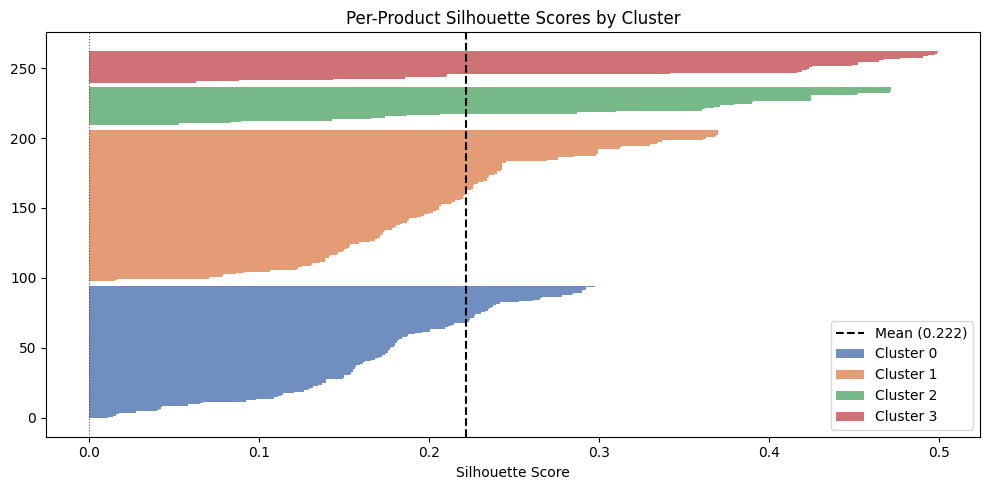

In [130]:
from sklearn.metrics import silhouette_samples
import matplotlib.pyplot as plt

sample_scores = silhouette_samples(X, km.labels_)
X_km['silhouette'] = sample_scores

# Count products by confidence band
firmly_assigned  = (sample_scores >= 0.3).sum()
moderate         = ((sample_scores >= 0.1) & (sample_scores < 0.3)).sum()
borderline       = ((sample_scores >= 0.0) & (sample_scores < 0.1)).sum()
misassigned      = (sample_scores < 0.0).sum()

print(f"Per-product silhouette breakdown (n=254):")
print(f"  Firmly assigned  (>= 0.3): {firmly_assigned}")
print(f"  Moderate       (0.1-0.3): {moderate}")
print(f"  Borderline     (0.0-0.1): {borderline}")
print(f"  Potentially misassigned (<0.0): {misassigned}")
print(f"\nMean silhouette: {sample_scores.mean():.3f}")
print(f"Min: {sample_scores.min():.3f}  |  Max: {sample_scores.max():.3f}")

# Plot silhouette scores by cluster
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
y_lower = 0
for cl in sorted(X_km['cluster'].unique()):
    cl_scores = sample_scores[X_km['cluster'] == cl]
    cl_scores_sorted = np.sort(cl_scores)
    y_upper = y_lower + len(cl_scores_sorted)
    ax.barh(range(y_lower, y_upper), cl_scores_sorted,
            height=1.0, color=colors[cl], alpha=0.8, label=f'Cluster {cl}')
    y_lower = y_upper + 3

ax.axvline(x=sample_scores.mean(), color='black', linestyle='--', label=f'Mean ({sample_scores.mean():.3f})')
ax.axvline(x=0, color='red', linestyle=':', linewidth=0.8)
ax.set_xlabel('Silhouette Score')
ax.set_title('Per-Product Silhouette Scores by Cluster')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [131]:
silhouette_sample_explanations = """
Per-product silhouette analysis identifies how confidently each of the 254 products
is assigned to its cluster. Products with scores above 0.3 sit firmly within their
archetype; scores between 0.1 and 0.3 indicate moderate confidence; scores below 0.1
are borderline — sitting near the boundary between two archetypes; negative scores
suggest the product may be closer to a neighbouring cluster.

Borderline products are not classification errors — they represent products whose
commercial profile genuinely shares characteristics across two archetypes. For a
category manager, these are the products that warrant manual review before applying
the archetype's pricing strategy, as a blanket intervention may not be appropriate.

The overall mean silhouette of 0.222 reflects that while the four archetypes are
commercially distinct, the feature space does not produce perfectly tight, well-
separated clusters — which is expected when clustering real product data across
20 heterogeneous features.
"""

In [132]:
print_tile(size='h3', key='silhouette_sample_explanations', value=silhouette_sample_explanations)

### I.5 Business Impact from Current Model Performance

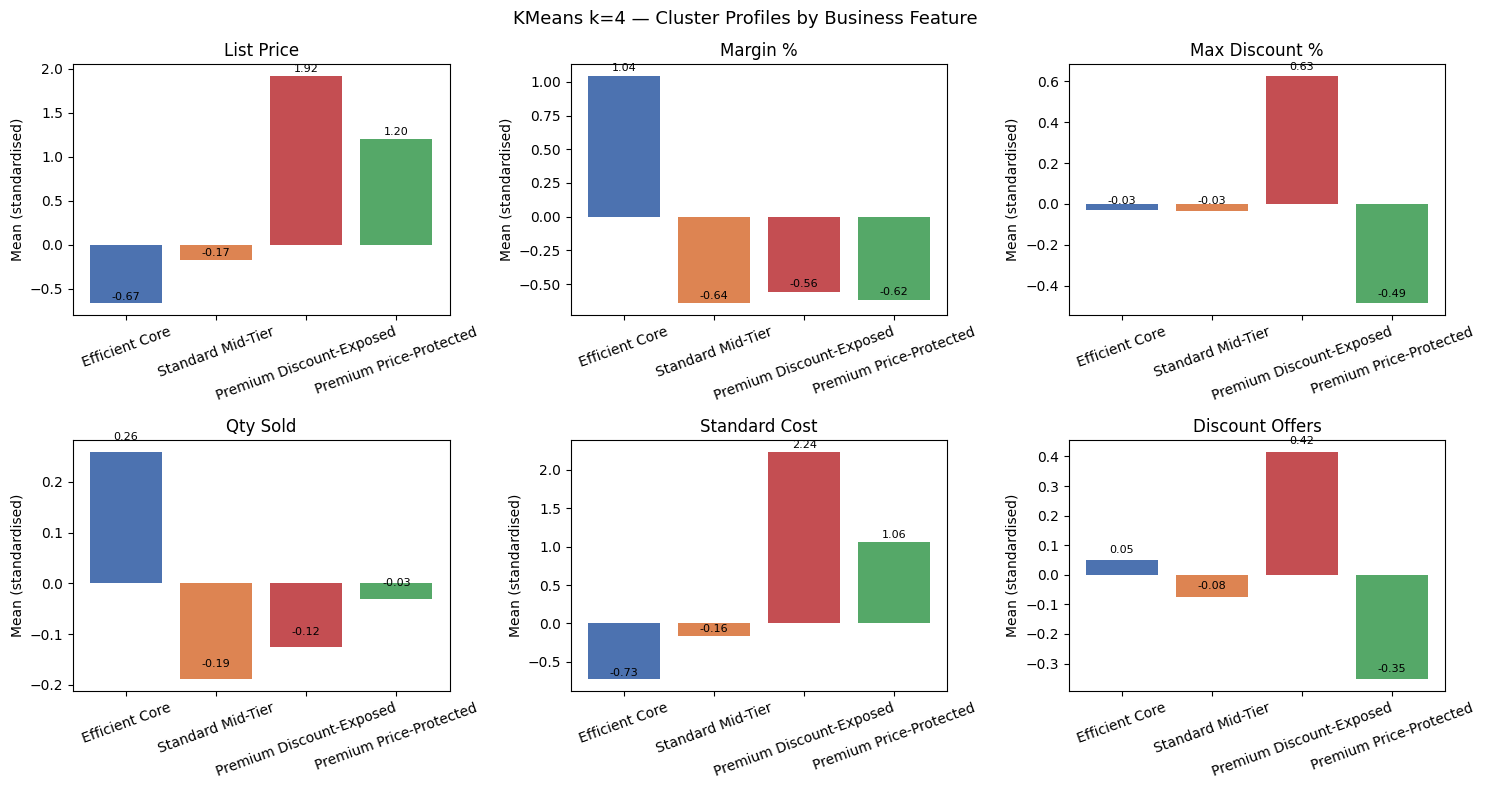

Cluster archetype summary:


,latest_list_price,estimated_margin_pct,max_discount_pct,total_quantity_sold,latest_standard_cost,num_discount_offers,n_products
archetype,,,,,,,
Efficient Core,-0.666,1.045,-0.030,0.259,-0.730,0.048,95
Premium Discount-Exposed,1.922,-0.558,0.628,-0.125,2.236,0.416,28
Premium Price-Protected,1.204,-0.617,-0.488,-0.030,1.062,-0.354,23
Standard Mid-Tier,-0.169,-0.643,-0.032,-0.189,-0.164,-0.075,108


In [133]:
# --- Cluster archetype names ---
archetype_names = {
    0: 'Efficient Core',
    1: 'Standard Mid-Tier',
    2: 'Premium Discount-Exposed',
    3: 'Premium Price-Protected'
}
X_km['archetype'] = X_km['cluster'].map(archetype_names)

# --- Bar chart: mean of key business features by cluster ---
business_cols = [
    'latest_list_price', 'estimated_margin_pct',
    'max_discount_pct', 'total_quantity_sold',
    'latest_standard_cost', 'num_discount_offers'
]
col_labels = [
    'List Price', 'Margin %',
    'Max Discount %', 'Qty Sold',
    'Standard Cost', 'Discount Offers'
]
colors = ['#4C72B0', '#DD8452', '#C44E52', '#55A868']
cluster_order = [0, 1, 2, 3]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(zip(business_cols, col_labels)):
    means_by_cluster = [
        X_km.loc[X_km['cluster'] == cl, col].mean()
        for cl in cluster_order
    ]
    bars = axes[i].bar(
        [archetype_names[cl] for cl in cluster_order],
        means_by_cluster,
        color=colors
    )
    axes[i].set_title(label)
    axes[i].set_ylabel('Mean (standardised)')
    axes[i].tick_params(axis='x', rotation=20)
    for bar, val in zip(bars, means_by_cluster):
        axes[i].text(bar.get_x() + bar.get_width() / 2,
                     bar.get_height() + 0.02, f'{val:.2f}',
                     ha='center', va='bottom', fontsize=8)

plt.suptitle('KMeans k=4 — Cluster Profiles by Business Feature', fontsize=13)
plt.tight_layout()
plt.show()

# --- Archetype summary table ---
archetype_summary = (
    X_km.groupby('archetype')[business_cols]
        .mean()
        .round(3)
        .join(X_km.groupby('archetype').size().rename('n_products'))
)
print('Cluster archetype summary:')
archetype_summary


In [134]:
# Raw-scale cluster profile — actual business units
ph      = pd.read_csv(at.folder_path / 'product_list_price_history.csv', parse_dates=['start_date'])
latest_price = ph.sort_values('start_date').groupby('product_id')['list_price'].last()

ch_hist = pd.read_csv(at.folder_path / 'product_cost_history.csv', parse_dates=['start_date'])
latest_cost  = ch_hist.sort_values('start_date').groupby('product_id')['standard_cost'].last()

sod = pd.read_csv(at.folder_path / 'sales_order_detail.csv')
qty = sod.groupby('product_id')['order_quantity'].sum()

sop   = pd.read_csv(at.folder_path / 'special_offer_product.csv')
so_df = pd.read_csv(at.folder_path / 'special_offer.csv')
max_disc = sop.merge(so_df[['special_offer_id','discount_pct']], on='special_offer_id') \
              .groupby('product_id')['discount_pct'].max()

raw_profile = pd.DataFrame({'product_id': X_train['product_id'], 'cluster': km.labels_})
raw_profile = raw_profile.set_index('product_id')
raw_profile['list_price']   = latest_price
raw_profile['std_cost']     = latest_cost
raw_profile['qty_sold']     = qty
raw_profile['max_disc_pct'] = max_disc.reindex(raw_profile.index).fillna(0)
raw_profile['margin_pct']   = (raw_profile['list_price'] - raw_profile['std_cost']) / raw_profile['list_price']
raw_profile['archetype']    = raw_profile['cluster'].map(archetype_names)

cluster_order = ['Efficient Core', 'Standard Mid-Tier', 'Premium Discount-Exposed', 'Premium Price-Protected']
profile = raw_profile.groupby('archetype').agg(
    n_products     = ('cluster',      'count'),
    avg_list_price = ('list_price',   'mean'),
    avg_std_cost   = ('std_cost',     'mean'),
    avg_margin_pct = ('margin_pct',   'mean'),
    avg_max_disc   = ('max_disc_pct', 'mean'),
    avg_qty_sold   = ('qty_sold',     'mean'),
).reindex(cluster_order)

display_df = profile.copy()
display_df['avg_list_price'] = display_df['avg_list_price'].map('${:,.0f}'.format)
display_df['avg_std_cost']   = display_df['avg_std_cost'].map('${:,.0f}'.format)
display_df['avg_margin_pct'] = display_df['avg_margin_pct'].map('{:.1%}'.format)
display_df['avg_max_disc']   = display_df['avg_max_disc'].map('{:.1%}'.format)
display_df['avg_qty_sold']   = display_df['avg_qty_sold'].map('{:,.0f}'.format)
display_df.columns = ['N Products', 'Avg List Price', 'Avg Std Cost', 'Avg Margin %', 'Avg Max Disc %', 'Avg Qty Sold']

print('Raw-scale cluster profile (actual business units):')
display_df

Raw-scale cluster profile (actual business units):


,N Products,Avg List Price,Avg Std Cost,Avg Margin %,Avg Max Disc %,Avg Qty Sold
archetype,,,,,,
Efficient Core,95,$82,$36,58.6%,7.8%,387
Standard Mid-Tier,108,$579,$351,39.4%,7.8%,204
Premium Discount-Exposed,28,"$2,783","$1,685",39.9%,16.9%,230
Premium Price-Protected,23,"$1,719","$1,032",39.6%,1.5%,269


In [135]:
business_impacts_explanations = """
The four clusters identify distinct margin-risk profiles across the 254-product
portfolio, each with different commercial implications. Raw-scale feature averages
are shown in the table above.

Cluster 0 — Efficient Core (95 products): low list price ($82 avg) and low standard
cost ($36 avg), delivering the highest margin percentage in the portfolio (58.6%).
These products generate reliable margin without requiring pricing intervention.
They represent the portfolio's low-risk base and should be protected from
unnecessary discounting.

Cluster 1 — Standard Mid-Tier (108 products): below-average price ($579 avg) and
cost ($351 avg) with below-average margin percentage (39.4%). This is the largest
group and carries moderate margin risk — margins are already compressed, meaning
any discount applied to these products directly erodes profitability without a
strong volume offset.

Cluster 2 — Premium Discount-Exposed (28 products): high list price ($2,783 avg)
and very high standard cost ($1,685 avg), combined with the highest discount
exposure in the portfolio (16.9% avg max discount). The margin percentage (~40%)
is similar to Clusters 1 and 3 — the risk is not a uniquely thin margin rate but
the absolute dollar exposure: a 16.9% discount on a $2,783 product represents
approximately $470 of revenue given away per sale. These products warrant the
most urgent pricing review.

Cluster 3 — Premium Price-Protected (23 products): high list price ($1,719 avg)
and above-average standard cost ($1,032 avg), with the lowest discount exposure
across all clusters (1.5% avg max discount). These are exclusively Mountain (39%)
and Road (61%) line products. Pricing discipline is already preserving margin
despite elevated cost levels.

Crucially, Clusters 2 and 3 occupy the same product tier — both premium, both
high-cost, both carrying approximately 40% margin percentage. The only material
difference is commercial management: Cluster 3 sustains premium prices with
minimal discounting (1.5%) while Cluster 2 is exposed to heavy discount pressure
(16.9%). Cluster 3 demonstrates that the pricing strategy is achievable for this
product type — the problem in Cluster 2 is operational, not structural.

Together the four archetypes give the category management team a targeted basis
for discount governance: protect Cluster 0 from unnecessary offers, monitor
Cluster 1 for creeping discount pressure, prioritise Cluster 2 for urgent pricing
review, and maintain the price discipline already in place for Cluster 3.
"""

In [136]:
# Do not modify this code
print_tile(size="h3", key='business_impacts_explanations', value=business_impacts_explanations)

## J. Model Comparison


In [137]:
comparison_data = {
    'Algorithm':         ['KMeans k=4', 'Mean Shift', 'Agglomerative Ward k=4'],
    'Silhouette':        [round(sil, 3),  0.278,  0.261],
    'Calinski-Harabasz': [round(ch, 1),   57.7,   58.1],
    'Davies-Bouldin':    [round(db, 3),   1.360,  1.326],
    'Cluster Sizes':     [
        str(sorted(X_km['cluster'].value_counts().tolist(), reverse=True)),
        '[168, 39, 28, 19]',
        '[177, 33, 26, 18]'
    ],
    'Selected': ['Yes', 'No', 'No']
}

comparison_df = pd.DataFrame(comparison_data).set_index('Algorithm')
print('Model Comparison:')
comparison_df

Model Comparison:


,Silhouette,Calinski-Harabasz,Davies-Bouldin,Cluster Sizes,Selected
Algorithm,,,,,
KMeans k=4,0.222,66.7,1.511,"[108, 95, 28, 23]",Yes
Mean Shift,0.278,57.7,1.360,"[168, 39, 28, 19]",No
Agglomerative Ward k=4,0.261,58.1,1.326,"[177, 33, 26, 18]",No


In [138]:
model_comparison_explanations = """
KMeans k=4 is selected as the final model on three grounds.

First, KMeans produces the highest Calinski-Harabasz score (66.7) across all three
algorithms. CH measures the ratio of between-cluster separation to within-cluster
compactness — a higher score means the clusters are more genuinely distinct from
each other. On this metric, KMeans produces the most well-defined product groups — meaning the four pricing archetypes are distinct enough that interventions designed for one segment are unlikely to overlap with or contradict those applied to another.

Second, KMeans produces the most balanced cluster sizes (95 / 108 / 28 / 23).
Mean Shift achieves a higher silhouette score (0.278 vs 0.222) but its cluster
distribution is heavily uneven — one cluster dominates the population while the
remaining clusters are substantially smaller. Small, tight clusters produce
inflated silhouette scores without representing commercially useful segments.
KMeans balanced distribution ensures that each identified product archetype
applies to a meaningful subset of the portfolio.

Third, KMeans centroids are directly interpretable as product archetype profiles.
Each centroid is a vector of mean feature values that a category manager can read
without statistical expertise. Agglomerative Ward achieves similar silhouette
(0.261) and DB (1.326) scores to KMeans but does not produce native centroids,
making segment communication and business application less direct.

KMeans with k-means++ initialisation and n_init=20 also produces stable,
reproducible assignments across runs — a practical requirement for a segmentation
that will be used in quarterly portfolio planning.
"""

In [139]:
# Do not modify this code
print_tile(size='h3', key='model_comparison_explanations', value=model_comparison_explanations)


## K. Project Outcomes


In [140]:
experiment_outcome = 'Hypothesis Confirmed'


In [141]:
# Do not modify this code
print_tile(size="h2", key='experiment_outcomes_explanations', value=experiment_outcome)

In [142]:
experiment_results_explanations = """
Outcome: The clustering experiment confirmed that the 254 sales-active products
separate into four structurally distinct commercial groups based on price, cost,
margin percentage, and discount behaviour. The hypothesis that meaningful margin-
risk archetypes exist within the portfolio — and that they can be identified
from commercial feature data alone — is supported.

Key insights:
1. The dominant split in the portfolio is between low-cost high-margin products
   (Efficient Core, 95 products, 58.6% avg margin) and mid-tier products with
   compressed margins (Standard Mid-Tier, 108 products, 39.4% avg margin).
   Together these two groups account for approximately 80% of the portfolio and
   represent the baseline for pricing governance.
2. A premium group (Premium Discount-Exposed, 28 products) carries the highest
   dollar risk in the portfolio — not because its margin percentage is uniquely
   thin (~40%, similar to Clusters 1 and 3), but because a 16.9% average max
   discount on a $2,783 average list price represents approximately $470 of
   revenue given away per sale. These products warrant the most urgent pricing
   review.
3. The comparison between Clusters 2 and 3 is the most commercially significant
   finding: both are premium, high-cost product groups with approximately 40%
   margin percentage. But Cluster 3 (Premium Price-Protected, 23 products)
   sustains its prices with just 1.5% average max discount, while Cluster 2 is
   exposed to 16.9%. Cluster 3 demonstrates that premium pricing is achievable
   for this product type — the problem in Cluster 2 is operational, not
   structural.
4. Two independent algorithms (KMeans and Mean Shift) both independently
   identified four density modes in the feature space, strengthening confidence
   that the four-archetype structure reflects genuine patterns rather than a
   modelling artefact.

Recommended next steps:
1. Pricing review for Cluster 2 (Premium Discount-Exposed): audit whether the
   high discount rates applied to these 28 products are commercially justified
   or are eroding margin without equivalent volume uplift. At approximately $470
   of revenue given away per sale, even a modest reduction in discount exposure
   on these products has an outsized impact on portfolio margin.
2. Discount governance for Cluster 1 (Standard Mid-Tier): establish discount
   band limits for this group — margins are already below average and further
   discounting directly reduces profitability.
3. Price protection for Cluster 3 (Premium Price-Protected): maintain current
   pricing discipline. Cluster 3 serves as the benchmark — it proves that
   premium pricing works without heavy discounts for this product tier. Any
   drift towards higher discount exposure risks replicating the Cluster 2
   problem.
4. Refresh the clustering quarterly or after material changes to the product
   mix, cost structure, or promotional calendar to ensure the archetypes remain
   current.
"""

In [143]:
# Do not modify this code
print_tile(size="h2", key='experiment_results_explanations', value=experiment_results_explanations)